In [1]:
import os
os.environ["PYTHONWARNINGS"] = "ignore"

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
import scanpy as sc
import squidpy as sq
import enrichmap as em
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import spottedpy as sp

from sklearn.preprocessing import MinMaxScaler
from tqdm import tqdm
from scipy.stats import spearmanr, zscore

In [4]:
sc.set_figure_params(frameon=False)
sc.settings._vector_friendly = False
plt.rcParams["axes.grid"] = False

In [5]:
# set working directory
project_dir = "/home/cenk/BreastCancerG0arrest/"
working_dir = project_dir + "00_revisions/"
os.chdir(working_dir)

# set figure directory
figure_dir = working_dir + "figures/"

# processed data directory
processed_data = working_dir + "data/"

In [6]:
adata = sc.read_h5ad(processed_data + "xenium_aligned_ductal_invasive.h5ad")

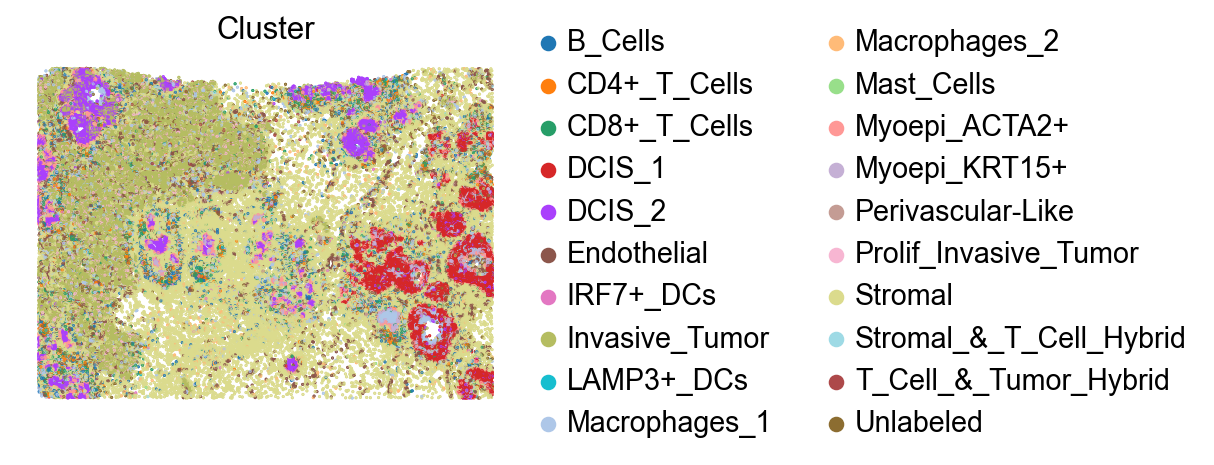

In [7]:
sq.pl.spatial_scatter(
    adata,
    shape=None,
    color=["Cluster"],
    cmap="seismic",
    size=0.5,
    save="xenium_cell_type.pdf"
)

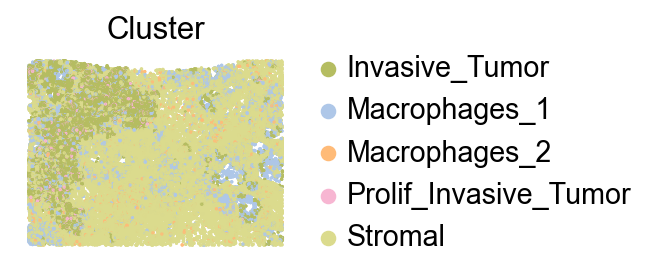

In [8]:
sq.pl.spatial_scatter(
    adata,
    shape=None,
    color=["Cluster"],
    groups=[
        "Macrophages_1",
        "Macrophages_2",
        "Invasive_Tumor",
        "Prolif_Invasive_Tumor",
        "Stromal",
    ],
    size=1,
)

In [9]:
adata.obs = adata.obs.rename(columns={"Cluster": "cell_type"})
adata.obs["cell_type"] = adata.obs["cell_type"].replace(
    {
        "Macrophages_1": "Macrophages",
        "Macrophages_2": "Macrophages",
        "Invasive_Tumor": "Invasive tumour",
        "Prolif_Invasive_Tumor": "Invasive tumour",
        "Stromal": "Stromal",
    }
)

In [10]:
adata.X = adata.layers["counts"].copy()

In [11]:
sc.pp.filter_genes(adata, min_cells=1)
sc.pp.normalize_total(adata, target_sum=1e4)
adata.X = np.log1p(adata.X)

In [12]:
import pickle

with open("gene_sets.pkl", "rb") as f:
    quiescence_genesets = pickle.load(f)

In [13]:
tumour_adata = adata[adata.obs["cell_type"].str.contains("umour")].copy()
tumour_adata.X = tumour_adata.layers["counts"].copy()
sc.pp.filter_genes(tumour_adata, min_cells=1)
sc.pp.normalize_total(tumour_adata, target_sum=1e4)
tumour_adata.X = np.log1p(tumour_adata.X)

In [14]:
from calculate_quiescence_score import score_quiescence

score_quiescence(
    tumour_adata,
    up_genes=quiescence_genesets["upregulated"],
    down_genes=quiescence_genesets["downregulated"]
    )

adata.obs.loc[adata.obs["cell_type"].str.contains("umour"), "G0_score"] = tumour_adata.obs[
    "quiescence_score"
]

In [15]:
adata_full = adata.copy()
adata = adata_full[adata_full.obs["cell_type"].str.contains("umour")].copy()

In [16]:
edu_proxy_genes = [
    "PCNA", "TK1", "RRM2", "RRM1", "MCM2", "MCM3", "MCM4", "MCM5", "MCM6",
    "MCM7", "CDC6", "CDC45", "ORC1", "ORC2", "POLE", "POLD1", "POLD3",
    "PRIM1", "PRIM2", "RPA1", "RPA2", "FEN1", "LIG1", "RFC4", "TOP2A",
    "CCNA2", "CCNE1", "GMNN", "HIST1H4C", "DNA2",
]

expr_df = pd.DataFrame(adata.X.toarray().T, index=adata.var_names, columns=adata.obs_names)

In [17]:
# Filter gene sets for intersection with available genes
edu_proxy_genes = [g for g in edu_proxy_genes if g in expr_df.index]

# Z-score per gene across cells
expr_z = pd.DataFrame(
    zscore(expr_df.values, axis=1, nan_policy="omit"),
    index=expr_df.index,
    columns=expr_df.columns,
)

# Store in adata.obs
adata.obs["edu_score"] = expr_z.loc[edu_proxy_genes].sum(axis=0) / np.sqrt(
    len(edu_proxy_genes)
)

In [18]:
# Step 1: Filter valid cells
valid_mask = adata.obs[["G0_score", "edu_score"]].notna().all(axis=1)
qs_vals = adata.obs.loc[valid_mask, "G0_score"].values
edu_vals = adata.obs.loc[valid_mask, "edu_score"].values
n_valid = valid_mask.sum()

# Step 2: Define stricter cut-off ranges
cutoff_range_lower = np.linspace(np.percentile(qs_vals, 1), -0.01, 50)
cutoff_range_upper = np.linspace(np.percentile(qs_vals, 70), np.percentile(qs_vals, 99), 50)

# Step 3: Initialise
best_score = -np.inf
best_lower = None
best_upper = None

# For plotting
score_records = []

# Step 4: Grid search
for lower in tqdm(cutoff_range_lower):
    for upper in cutoff_range_upper:
        if upper <= lower + 0.05:
            continue

        cats = np.full(n_valid, "Slow-cycling", dtype=object)
        cats[qs_vals <= lower] = "Fast-cycling"
        cats[qs_vals >= upper] = "G0-arrested"

        df_valid = pd.DataFrame(
            {
                "G0_score": qs_vals,
                "edu_score": edu_vals,
                "cycling_state": cats,
            }
        )

        df_fast = df_valid[df_valid["cycling_state"] == "Fast-cycling"]
        df_g0 = df_valid[df_valid["cycling_state"] == "G0-arrested"]
        df_slow = df_valid[df_valid["cycling_state"] == "Slow-cycling"]

        if any(len(g) < 0.05 * n_valid for g in [df_fast, df_g0, df_slow]):
            continue

        try:
            corr_fast = spearmanr(-df_fast["G0_score"], df_fast["edu_score"])[0]
            corr_g0 = spearmanr(df_g0["G0_score"], df_g0["edu_score"])[0]
        except ValueError:
            continue

        score = corr_fast - corr_g0
        score_records.append((lower, upper, score))

        if score > best_score:
            best_score = score
            best_lower = lower
            best_upper = upper

# Convert records to DataFrame for plotting
df_scores = pd.DataFrame(score_records, columns=["lower", "upper", "score"])

# Step 5: Assign final categories to all cells
def assign_cycling_state(row):
    q = row["G0_score"]
    e = row["edu_score"]
    if pd.isna(q) or pd.isna(e):
        return "Unknown"
    if q <= best_lower:
        return "Fast-cycling"
    elif q >= best_upper:
        return "G0-arrested"
    else:
        return "Slow-cycling"

adata.obs["cycling_state"] = adata.obs.apply(assign_cycling_state, axis=1)

# Step 6: Report
print("Final optimised cut-offs:")
print(f" Fast-cycling ≤ {best_lower:.3f}")
print(f" G0-arrested ≥ {best_upper:.3f}")
print(f" Total correlation score: {best_score:.3f}")
print(adata.obs["cycling_state"].value_counts())

100%|██████████| 50/50 [00:29<00:00,  1.70it/s]


Final optimised cut-offs:
 Fast-cycling ≤ -0.010
 G0-arrested ≥ 2.086
 Total correlation score: 0.414
cycling_state
Fast-cycling    16662
Slow-cycling    15985
G0-arrested      2374
Name: count, dtype: int64


In [19]:
# put back to full adata
adata_full.obs["cycling_state"] = np.nan
adata_full.obs.loc[adata.obs_names, "cycling_state"] = adata.obs["cycling_state"]
adata = adata_full.copy()

In [20]:
adata.uns["cycling_state_colors"] = ["#2FBF71", "#6A5ACD", "#8C8C8C"]

In [21]:
def plot_overlaid_spatial(
    adata,
    layers,
    figsize=(10, 10),
    background_color="lightgrey",
    background_size=0.5,
    save=None,
):
    """
    Plot multiple cell types/states overlaid on a single spatial plot.

    Parameters
    ----------
    adata : AnnData
        Annotated data object with spatial coordinates in adata.obsm["spatial"].
    layers : list of dict
        Each dict specifies a layer to plot with keys:
        - "mask": boolean array or column name for filtering cells
        - "color": color for this layer (can be a column name for continuous coloring)
        - "cmap": colormap for continuous values (optional)
        - "label": legend label
        - "size": point size (default 1)
        - "alpha": transparency (default 1)
        - "vmin", "vmax", "vcenter": for continuous color scaling (optional)
    figsize : tuple
        Figure size.
    background_color : str
        Color for background (non-highlighted) cells.
    background_size : float
        Size for background points.
    save : str, optional
        Path to save the figure.

    Returns
    -------
    fig, ax : matplotlib figure and axis
    """
    import matplotlib.pyplot as plt
    from matplotlib.colors import Normalize, TwoSlopeNorm
    import numpy as np

    fig, ax = plt.subplots(figsize=figsize)

    # Get spatial coordinates
    coords = adata.obsm["spatial"]

    # Plot background cells in light grey
    ax.scatter(
        coords[:, 0],
        coords[:, 1],
        c=background_color,
        s=background_size,
        alpha=0.3,
        rasterized=True,
    )

    # Plot each layer
    for layer in layers:
        # Get mask
        if isinstance(layer["mask"], str):
            mask = adata.obs[layer["mask"]].values
        else:
            mask = layer["mask"]

        subset_coords = coords[mask]
        size = layer.get("size", 1)
        alpha = layer.get("alpha", 1)
        label = layer.get("label", None)

        # Handle color - can be a single color or a column for continuous coloring
        color = layer["color"]
        if isinstance(color, str) and color in adata.obs.columns:
            # Continuous coloring
            values = adata.obs.loc[mask, color].values
            cmap = layer.get("cmap", "viridis")
            vmin = layer.get("vmin", np.nanmin(values))
            vmax = layer.get("vmax", np.nanmax(values))
            vcenter = layer.get("vcenter", None)

            if vcenter is not None:
                norm = TwoSlopeNorm(vmin=vmin, vcenter=vcenter, vmax=vmax)
            else:
                norm = Normalize(vmin=vmin, vmax=vmax)

            sc_plot = ax.scatter(
                subset_coords[:, 0],
                subset_coords[:, 1],
                c=values,
                cmap=cmap,
                norm=norm,
                s=size,
                alpha=alpha,
                label=label,
                rasterized=True,
            )
            plt.colorbar(sc_plot, ax=ax, label=label, shrink=0.5)
        else:
            # Single color
            ax.scatter(
                subset_coords[:, 0],
                subset_coords[:, 1],
                c=color,
                s=size,
                alpha=alpha,
                label=label,
                rasterized=True,
            )

    ax.set_aspect("equal")
    ax.axis("off")
    ax.legend(loc="upper right", frameon=False)

    plt.tight_layout()

    if save:
        plt.savefig(save, dpi=300, bbox_inches="tight")

    plt.show()
    return fig, ax

## CXCL10+ Macrophage Analysis

### Generate CXCL10 Macrophage Signature

In [22]:
adata_sc = sc.read_h5ad("data/Wu_etal_2021_BRCA_scRNASeq_processed_with_quiescence_scores.h5ad")

In [23]:
adata_sc.X = adata_sc.layers["counts"].copy()

In [24]:
from scipy.sparse import issparse
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats

adata_sc.obs["group"] = np.where(
    adata_sc.obs["celltype_subset"] == "Myeloid_c9_Macrophage_2_CXCL10",
    "CXCL10_macrophage",
    "Rest",
)

# Create pseudo-replicates
replicate = 3
rng = np.random.default_rng(0)

rep_labels = []
for grp in ["CXCL10_macrophage", "Rest"]:
    mask = adata_sc.obs["group"] == grp
    n = mask.sum()
    assignments = rng.integers(0, replicate, size=n)
    rep_labels.append(
        pd.Series(
            [f"{grp}_rep{i}" for i in assignments],
            index=adata_sc.obs_names[mask],
        )
    )
adata_sc.obs["pseudo_rep"] = pd.concat(rep_labels)

# Aggregate raw counts per pseudo-replicate
counts_mat = adata_sc.raw.X if adata_sc.raw is not None else adata_sc.X

# densify if sparse
if issparse(counts_mat):
    counts_mat = counts_mat.toarray()

counts_df = pd.DataFrame(
    counts_mat,
    index=adata_sc.obs_names,
    columns=(adata_sc.raw.var_names if adata_sc.raw is not None else adata_sc.var_names),
)
counts_df["pseudo_rep"] = adata_sc.obs["pseudo_rep"]

pseudobulk = counts_df.groupby("pseudo_rep").sum()

# Build sample metadata
sample_meta = pd.DataFrame({"pseudo_rep": pseudobulk.index})
sample_meta["group"] = sample_meta["pseudo_rep"].str.rsplit("_rep", n=1).str[0]
sample_meta = sample_meta.set_index("pseudo_rep")

# Pre-filter low-count genes
gene_keep = pseudobulk.columns[pseudobulk.sum(axis=0) >= 10]
pseudobulk = pseudobulk[gene_keep]

dds = DeseqDataSet(
    counts=pseudobulk,
    metadata=sample_meta,
    design="~group",
    ref_level=["group", "Rest"],
)

dds.deseq2()

stat = DeseqStats(dds, contrast=["group", "CXCL10_macrophage", "Rest"])
stat.summary()

results = stat.results_df.copy()

# Filter for upregulated genes in CXCL10_macrophage vs Rest
up = results[(results["padj"] < 0.01) & (results["log2FoldChange"] > 2)].sort_values(
    "log2FoldChange", ascending=False
)

Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.01 seconds.

Fitting dispersions...
... done in 2.54 seconds.

Fitting dispersion trend curve...
... done in 0.41 seconds.

Fitting MAP dispersions...
... done in 2.09 seconds.

Fitting LFCs...
... done in 3.39 seconds.

Calculating cook's distance...
... done in 0.02 seconds.

Replacing 0 outlier genes.

Running Wald tests...


Log2 fold change & Wald test p-value: group CXCL10_macrophage vs Rest
                 baseMean  log2FoldChange     lfcSE      stat        pvalue  \
RP11-34P13.7     1.995918       -0.765720  1.948791 -0.392921  6.943780e-01   
FO538757.3       3.867523        0.572261  1.400821  0.408518  6.828932e-01   
FO538757.2     465.188938        0.974694  0.127948  7.617869  2.578969e-14   
AP006222.2     147.949459       -0.050967  0.253203 -0.201289  8.404729e-01   
RP4-669L17.10   11.221866        0.399071  0.841368  0.474312  6.352774e-01   
...                   ...             ...       ...       ...           ...   
RP11-503D12.1    1.651743       -0.493114  1.948243 -0.253107  8.001854e-01   
AL121578.2       0.940464        0.319663  1.955798  0.163444  8.701691e-01   
CXADRP3          2.325157       -0.986449  1.945563 -0.507025  6.121372e-01   
RP11-5P18.5      0.508428        1.207213  1.959402  0.616113  5.378197e-01   
LINC00550        0.304719        1.944406  1.968332  0.987844

... done in 2.64 seconds.



In [25]:
print(f"Upregulated genes in CXCL10_macrophage: {len(up)}")
gene_set_mac = up.head(500).index.tolist()

Upregulated genes in CXCL10_macrophage: 1102


### Score Xenium - CXCL10+ Macrophages

In [26]:
adata_mac = adata[adata.obs["cell_type"].str.contains("Macrophages")].copy()
adata_mac.X = adata_mac.layers["counts"].copy()
sc.pp.filter_genes(adata_mac, min_cells=1)
sc.pp.normalize_total(adata_mac, target_sum=1e4)
adata_mac.X = np.log1p(adata_mac.X)

In [27]:
gene_set_mac = [g for g in gene_set_mac if g in adata_mac.var_names]
print(f"Available genes: {len(gene_set_mac)}")

Available genes: 29


In [28]:
em.tl.score(adata_mac, gene_set_mac, score_key="CXCL10_macrophage")

Scoring signatures: 100%|██████████| 1/1 [00:00<00:00,  1.42it/s]


In [29]:
adata.obs["CXCL10_macrophage_score"] = np.nan
adata.obs.loc[adata_mac.obs_names, "CXCL10_macrophage_score"] = adata_mac.obs["CXCL10_macrophage_score"]

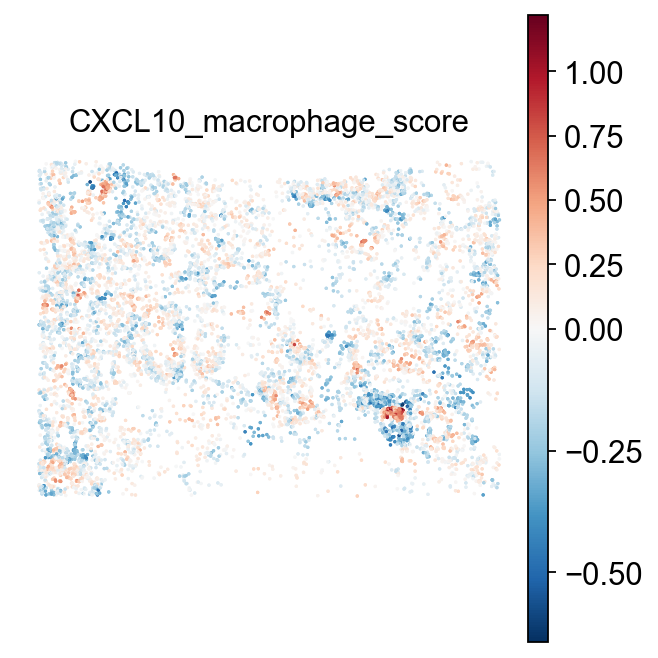

In [30]:
sq.pl.spatial_scatter(
    adata[adata.obs["cell_type"].str.contains("Macrophages")],
    shape=None,
    color=["CXCL10_macrophage_score"],
    size=1,
    vcenter=0,
    cmap="RdBu_r",
    save=figure_dir + "xenium_cxcl10_macrophage_score.pdf",
)

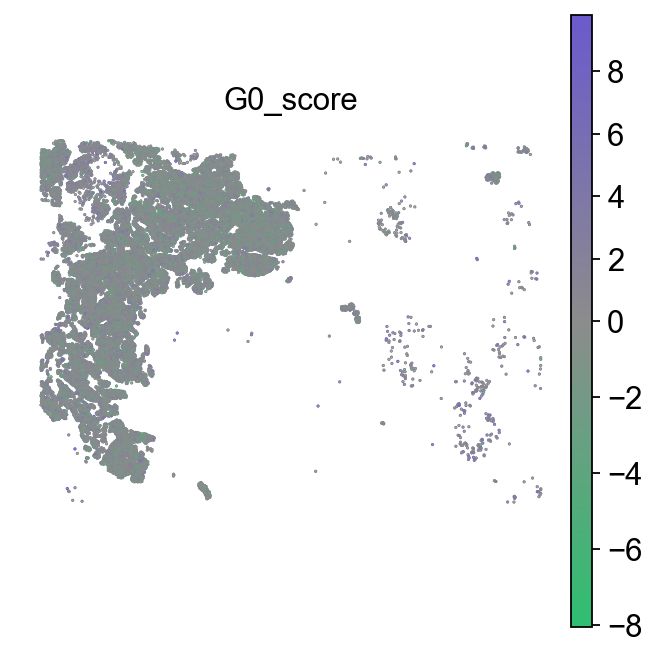

In [31]:
from matplotlib.colors import LinearSegmentedColormap

cmap = LinearSegmentedColormap.from_list("quiescence", ["#2FBF71", "#8C8C8C", "#6A5ACD"], N=256)

sq.pl.spatial_scatter(
    adata[adata.obs["cell_type"].str.contains("umour")],
    shape=None,
    color=["G0_score"],
    size=0.5,
    cmap=cmap,
    vcenter=0,
    save=figure_dir + "xenium_g0_score_tumours.pdf",
)

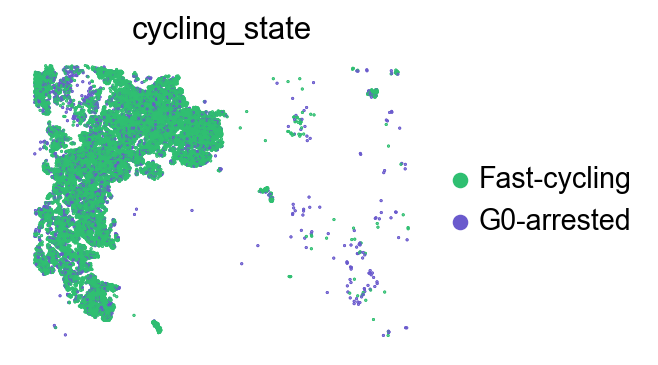

In [32]:
sq.pl.spatial_scatter(
    adata,
    shape=None,
    color=["cycling_state"],
    groups=["G0-arrested", "Fast-cycling"],
    size=0.5,
    save=figure_dir + "xenium_tumours.pdf",
)

### Hotspot Analysis - CXCL10+ Macrophages

In [33]:
# Scale CXCL10_macrophage_score
scaler = MinMaxScaler()
adata.obs["CXCL10_macrophage_score"] = scaler.fit_transform(adata.obs[["CXCL10_macrophage_score"]])

In [34]:
# Spatial coordinates setup (shared for both hotspot analyses)
adata.obs["batch"] = "Xenium"

if "spatial" in adata.obsm:
    adata.obs["array_row"] = adata.obsm["spatial"][:, 1]  # y-coordinate
    adata.obs["array_col"] = adata.obsm["spatial"][:, 0]  # x-coordinate
    print("Added 'array_row' and 'array_col' from adata.obsm['spatial']")
else:
    print("Warning: 'spatial' key not found in adata.obsm")
    print(f"Available keys: {list(adata.obsm.keys())}")

Added 'array_row' and 'array_col' from adata.obsm['spatial']


In [35]:
adata = sp.create_hotspots(
    adata,
    column_name="CXCL10_macrophage_score",
    neighbours_parameters=6,
    relative_to_batch=True,
    filter_columns="cell_type",
    filter_value="Macrophages",
)

In [36]:
# Simplify tumour cell type label
adata.obs["cell_type"] = np.where(
    adata.obs["cell_type"].str.contains("umour"),
    "Tumour",
    adata.obs["cell_type"],
)

In [37]:
adata_subset_mac = adata[
    (adata.obs["cycling_state"].isin(["G0-arrested", "Fast-cycling"]))
    | (adata.obs["cell_type"] == "Macrophages")
].copy()

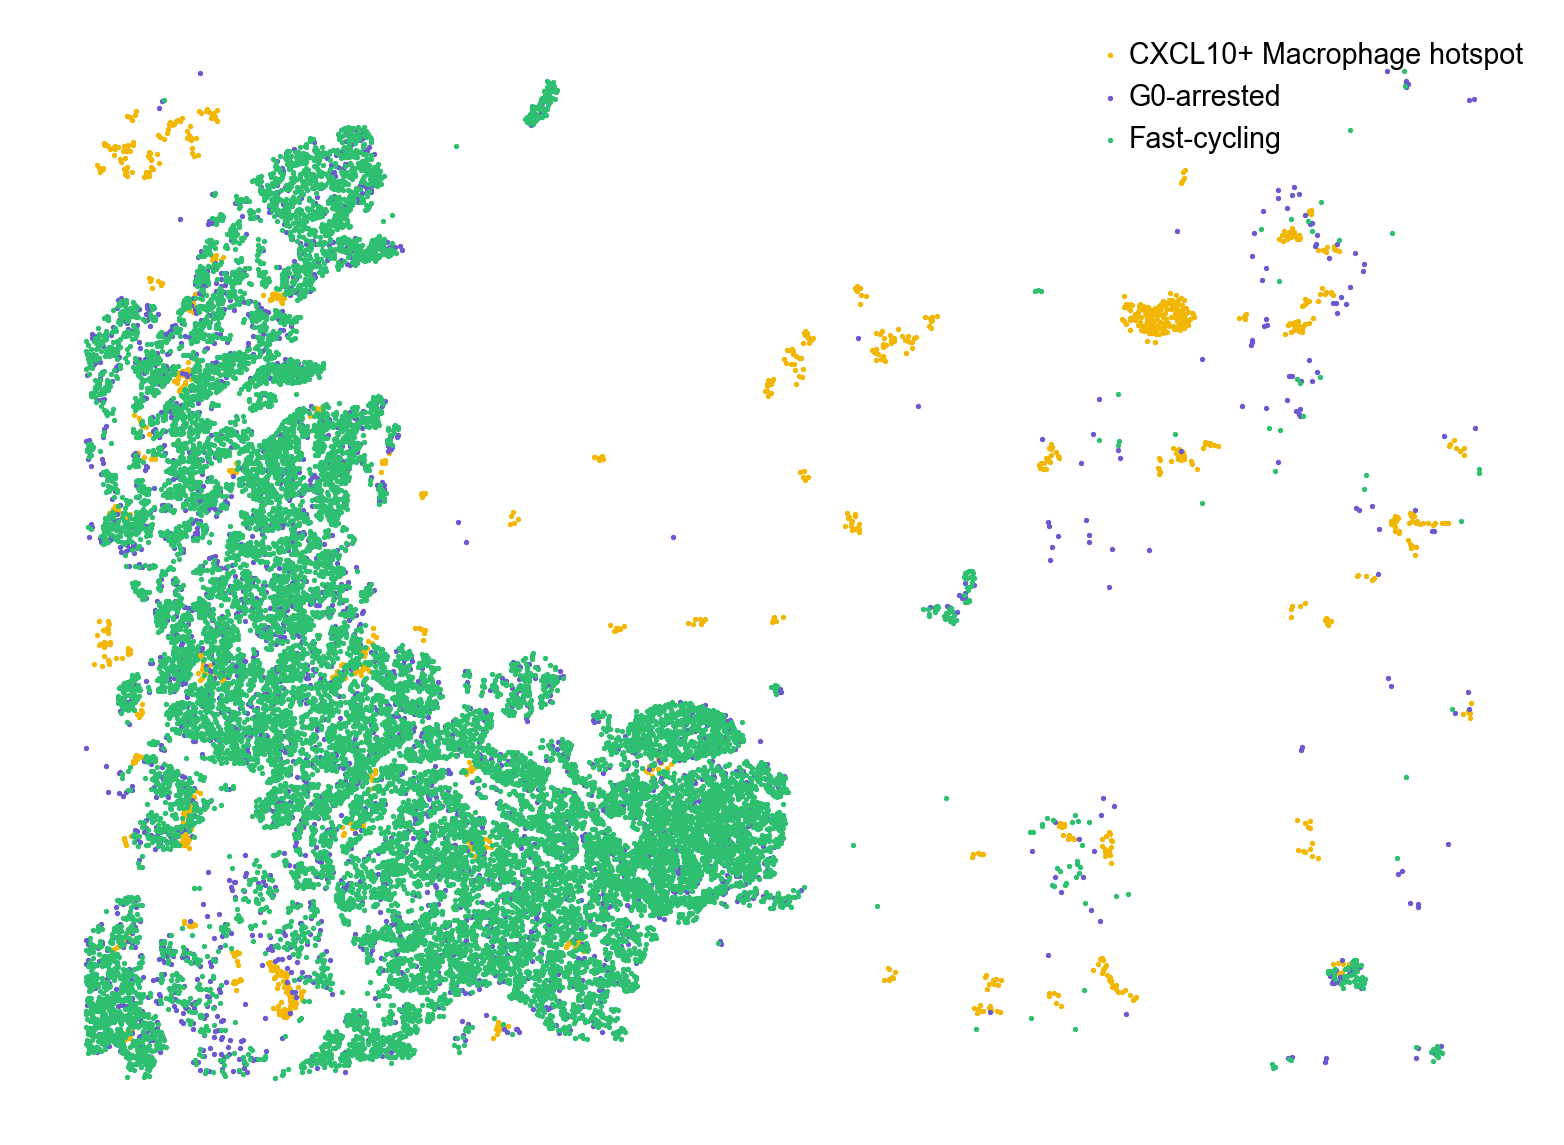

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [38]:
plot_overlaid_spatial(
    adata_subset_mac,
    layers=[
        {
            "mask": (adata_subset_mac.obs["CXCL10_macrophage_score_hot"].notna()).values,
            "color": "#F2B705",
            "label": "CXCL10+ Macrophage hotspot",
            "size": 2,
        },
        {
            "mask": (adata_subset_mac.obs["cycling_state"] == "G0-arrested").values,
            "color": "#6A5ACD",
            "label": "G0-arrested",
            "size": 2,
        },
        {
            "mask": (adata_subset_mac.obs["cycling_state"] == "Fast-cycling").values,
            "color": "#2FBF71",
            "label": "Fast-cycling",
            "size": 2,
        },
    ],
    background_color="white",
    figsize=(10, 10),
    save=figure_dir + "xenium_g0_fast_cxcl10_mac.pdf",
)

### Distance Quantification: CXCL10+ Macrophages to G0-arrested and Fast-cycling cells

In [39]:
from sklearn.cluster import DBSCAN
from scipy.spatial.distance import cdist

# Get spatial coordinates for each cell type
g0_mask = adata.obs["cycling_state"] == "G0-arrested"
fast_mask = adata.obs["cycling_state"] == "Fast-cycling"
mac_hot_mask = adata.obs["CXCL10_macrophage_score_hot"].notna()

g0_coords = adata.obsm["spatial"][g0_mask.values]
fast_coords = adata.obsm["spatial"][fast_mask.values]
mac_hot_coords = adata.obsm["spatial"][mac_hot_mask.values]

print(f"G0-arrested cells: {len(g0_coords)}")
print(f"Fast-cycling cells: {len(fast_coords)}")
print(f"CXCL10+ Macrophage hotspot cells: {len(mac_hot_coords)}")

G0-arrested cells: 2374
Fast-cycling cells: 16662
CXCL10+ Macrophage hotspot cells: 1111


In [40]:
# Cluster G0-arrested and Fast-cycling cells using DBSCAN
eps_g0 = 50
eps_fast = 50
min_samples_g0 = 10
min_samples_fast = 10

g0_clustering = DBSCAN(eps=eps_g0, min_samples=min_samples_g0).fit(g0_coords)
g0_labels = g0_clustering.labels_

fast_clustering = DBSCAN(eps=eps_fast, min_samples=min_samples_fast).fit(fast_coords)
fast_labels = fast_clustering.labels_

# Cluster CXCL10+ Macrophage hotspots
mac_clustering = DBSCAN(eps=50, min_samples=5).fit(mac_hot_coords)
mac_labels = mac_clustering.labels_

print(f"G0 clusters found: {len(set(g0_labels)) - (1 if -1 in g0_labels else 0)}")
print(f"Fast-cycling clusters found: {len(set(fast_labels)) - (1 if -1 in fast_labels else 0)}")
print(f"CXCL10+ Macrophage hotspot clusters found: {len(set(mac_labels)) - (1 if -1 in mac_labels else 0)}")

G0 clusters found: 2
Fast-cycling clusters found: 43
CXCL10+ Macrophage hotspot clusters found: 91


In [41]:
# Calculate cluster centroids
def get_cluster_centroids(coords, labels):
    """Calculate centroids for each cluster (excluding noise label -1)."""
    centroids = {}
    unique_labels = set(labels)
    for label in unique_labels:
        if label == -1:
            continue
        mask = labels == label
        centroids[label] = coords[mask].mean(axis=0)
    return centroids

g0_centroids = get_cluster_centroids(g0_coords, g0_labels)
fast_centroids = get_cluster_centroids(fast_coords, fast_labels)
mac_centroids = get_cluster_centroids(mac_hot_coords, mac_labels)

print(f"G0 cluster centroids: {len(g0_centroids)}")
print(f"Fast-cycling cluster centroids: {len(fast_centroids)}")
print(f"CXCL10+ Macrophage cluster centroids: {len(mac_centroids)}")

G0 cluster centroids: 2
Fast-cycling cluster centroids: 43
CXCL10+ Macrophage cluster centroids: 91


In [42]:
# Centroid-to-centroid distances: CXCL10+ Macrophage clusters → G0 and Fast-cycling clusters
if len(mac_centroids) > 0 and len(g0_centroids) > 0:
    mac_centroid_arr = np.array(list(mac_centroids.values()))
    g0_centroid_arr = np.array(list(g0_centroids.values()))

    mac_to_g0_dists = cdist(mac_centroid_arr, g0_centroid_arr)
    mac_to_g0_min = mac_to_g0_dists.min(axis=1)

    print("CXCL10+ Macrophage to G0-arrested cluster distances (centroid-to-centroid):")
    print(f"  Mean minimum distance: {mac_to_g0_min.mean():.2f}")
    print(f"  Median minimum distance: {np.median(mac_to_g0_min):.2f}")
    print(f"  Std: {mac_to_g0_min.std():.2f}")
    print(f"  Range: [{mac_to_g0_min.min():.2f}, {mac_to_g0_min.max():.2f}]")

if len(mac_centroids) > 0 and len(fast_centroids) > 0:
    mac_centroid_arr = np.array(list(mac_centroids.values()))
    fast_centroid_arr = np.array(list(fast_centroids.values()))

    mac_to_fast_dists = cdist(mac_centroid_arr, fast_centroid_arr)
    mac_to_fast_min = mac_to_fast_dists.min(axis=1)

    print("CXCL10+ Macrophage to Fast-cycling cluster distances (centroid-to-centroid):")
    print(f"  Mean minimum distance: {mac_to_fast_min.mean():.2f}")
    print(f"  Median minimum distance: {np.median(mac_to_fast_min):.2f}")
    print(f"  Std: {mac_to_fast_min.std():.2f}")
    print(f"  Range: [{mac_to_fast_min.min():.2f}, {mac_to_fast_min.max():.2f}]")

CXCL10+ Macrophage to G0-arrested cluster distances (centroid-to-centroid):
  Mean minimum distance: 2945.99
  Median minimum distance: 2342.07
  Std: 1779.49
  Range: [115.20, 6585.14]
CXCL10+ Macrophage to Fast-cycling cluster distances (centroid-to-centroid):
  Mean minimum distance: 925.72
  Median minimum distance: 692.35
  Std: 781.00
  Range: [56.04, 2718.04]


### Paired log-ratio analysis — abundance-robust proximity test

Fast-cycling cells vastly outnumber G0-arrested cells, so a simple nearest-neighbour
distance will almost always place a fast-cycling cell closer by chance. Instead, for
each CXCL10+ macrophage we compute BOTH distances simultaneously and test:
is d₀ < dᴹ⁰ within the same cell?

`log2_ratio = log2(d_Fast / d_G0)`
- `> 0` → G0 cell is the closer population
- `< 0` → Fast-cycling cell is closer

In [43]:
# Cell-level analysis: distance from each CXCL10+ Macrophage to nearest G0 / Fast-cycling cell
from scipy.spatial import cKDTree

# Build KD-trees for G0-arrested and Fast-cycling cells
g0_tree   = cKDTree(g0_coords)
fast_tree = cKDTree(fast_coords)

# Distance from each CXCL10+ Macrophage cell to nearest G0-arrested cell
mac_to_g0_cell_dist,   _ = g0_tree.query(mac_hot_coords,   k=1)

# Distance from each CXCL10+ Macrophage cell to nearest Fast-cycling cell
mac_to_fast_cell_dist, _ = fast_tree.query(mac_hot_coords, k=1)

print("CXCL10+ Macrophage to nearest G0-arrested cell:")
print(f"  Mean distance  : {mac_to_g0_cell_dist.mean():.2f}")
print(f"  Median distance: {np.median(mac_to_g0_cell_dist):.2f}")
print(f"  Std            : {mac_to_g0_cell_dist.std():.2f}")

print("\nCXCL10+ Macrophage to nearest Fast-cycling cell:")
print(f"  Mean distance  : {mac_to_fast_cell_dist.mean():.2f}")
print(f"  Median distance: {np.median(mac_to_fast_cell_dist):.2f}")
print(f"  Std            : {mac_to_fast_cell_dist.std():.2f}")

# Paired log2 ratio
mac_log2_ratio = np.log2(mac_to_fast_cell_dist / mac_to_g0_cell_dist)

print(f"\nCXCL10+ macrophages analysed     : {len(mac_log2_ratio)}")
print(f"% where G0 is closer             : {(mac_log2_ratio > 0).mean()*100:.1f}%")
print(f"% where Fast-cycling is closer   : {(mac_log2_ratio < 0).mean()*100:.1f}%")
print(f"Median log2(d_Fast/d_G0)         : {np.median(mac_log2_ratio):.3f}")

CXCL10+ Macrophage to nearest G0-arrested cell:
  Mean distance  : 176.99
  Median distance: 122.61
  Std            : 158.95

CXCL10+ Macrophage to nearest Fast-cycling cell:
  Mean distance  : 284.47
  Median distance: 181.64
  Std            : 312.85

CXCL10+ macrophages analysed     : 1111
% where G0 is closer             : 65.0%
% where Fast-cycling is closer   : 35.0%
Median log2(d_Fast/d_G0)         : 0.289


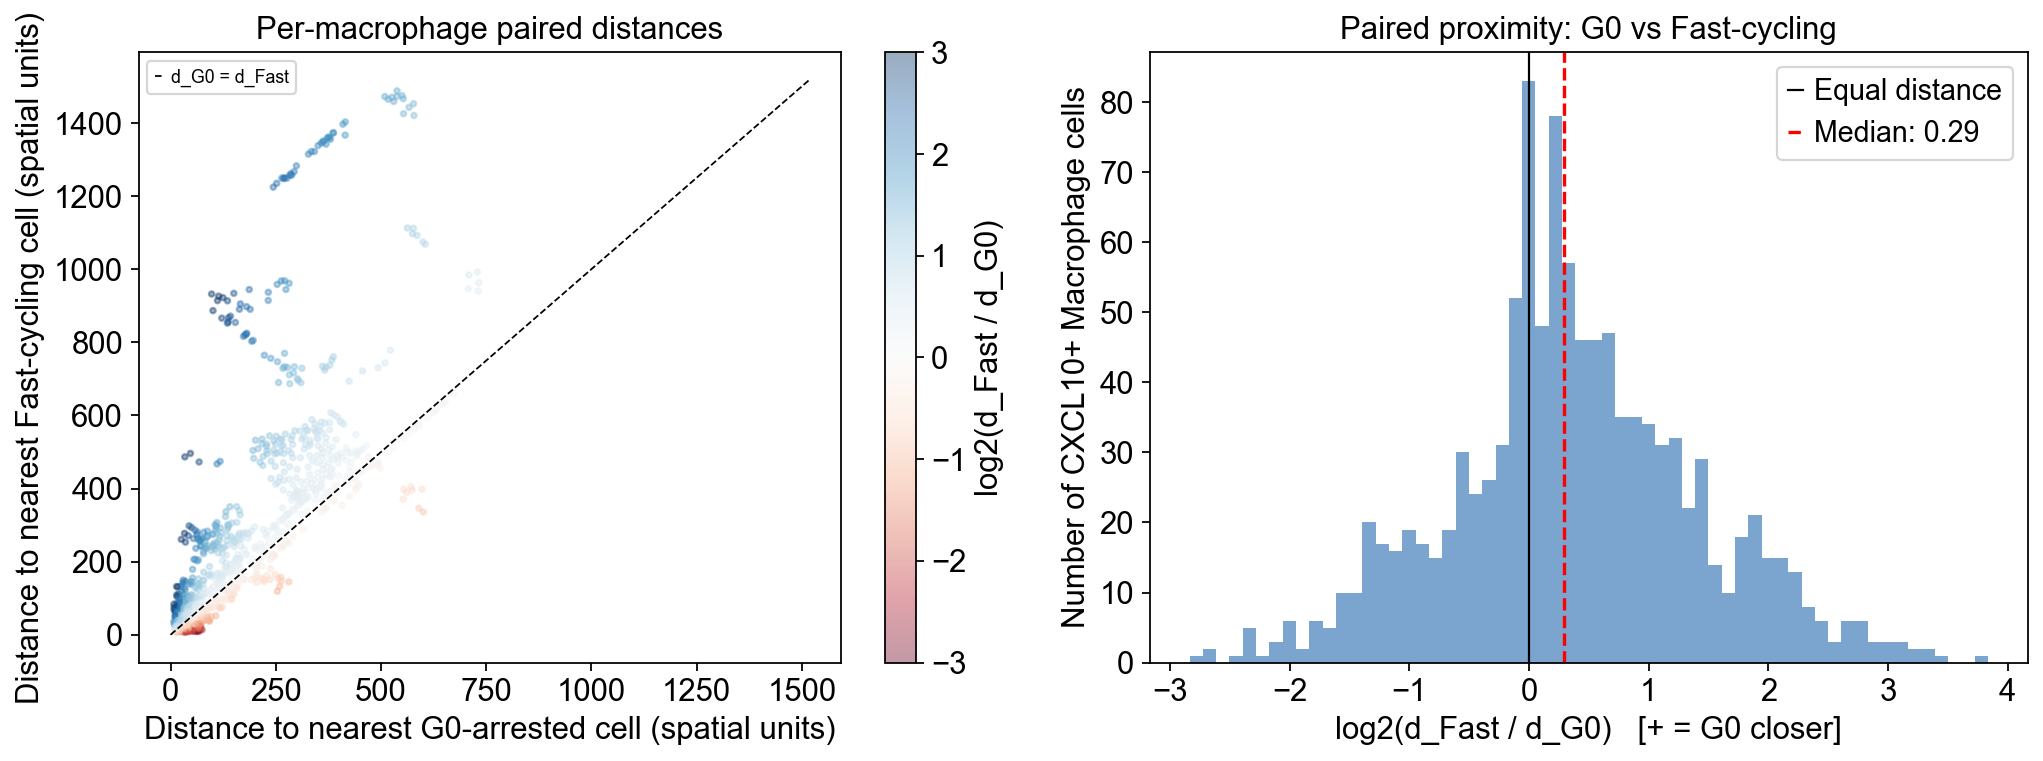

In [44]:
# Paired scatter: d_G0 vs d_Fast per CXCL10+ macrophage, coloured by log2 ratio
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Left: scatter d_G0 vs d_Fast ---
sc_plot = axes[0].scatter(
    mac_to_g0_cell_dist, mac_to_fast_cell_dist,
    c=mac_log2_ratio, cmap="RdBu", alpha=0.4, s=6, vmin=-3, vmax=3
)
lim = max(mac_to_g0_cell_dist.max(), mac_to_fast_cell_dist.max()) * 1.02
axes[0].plot([0, lim], [0, lim], "k--", lw=0.8, label="d_G0 = d_Fast")
axes[0].set_xlabel("Distance to nearest G0-arrested cell (spatial units)")
axes[0].set_ylabel("Distance to nearest Fast-cycling cell (spatial units)")
axes[0].set_title("Per-macrophage paired distances")
axes[0].legend(fontsize=8)
plt.colorbar(sc_plot, ax=axes[0], label="log2(d_Fast / d_G0)")

# --- Right: histogram of log2 ratio ---
axes[1].hist(mac_log2_ratio, bins=60, color="#5A8FC3", edgecolor="none", alpha=0.8)
axes[1].axvline(0, color="black", lw=1, linestyle="-", label="Equal distance")
axes[1].axvline(np.median(mac_log2_ratio), color="red", lw=1.5, linestyle="--",
                label=f"Median: {np.median(mac_log2_ratio):.2f}")
axes[1].set_xlabel("log2(d_Fast / d_G0)   [+ = G0 closer]")
axes[1].set_ylabel("Number of CXCL10+ Macrophage cells")
axes[1].set_title("Paired proximity: G0 vs Fast-cycling")
axes[1].legend()

plt.tight_layout()
plt.savefig(figure_dir + "xenium_cxcl10mac_paired_proximity.pdf", dpi=300, bbox_inches="tight")
plt.show()

In [45]:
# Wilcoxon signed-rank test on log2(d_Fast / d_G0)
# H0: median log2 ratio = 0  (G0 and Fast-cycling are equidistant)
from scipy.stats import wilcoxon

mac_stat_w, mac_pval_w = wilcoxon(mac_log2_ratio, alternative="two-sided")
mac_stat_greater, mac_pval_greater = wilcoxon(mac_log2_ratio, alternative="greater")

print("Wilcoxon signed-rank test on log2(d_Fast / d_G0) — CXCL10+ Macrophages:")
print(f"  Two-sided                             : stat={mac_stat_w:.2f}, p={mac_pval_w:.2e}")
print(f"  One-sided (H1: G0 closer, ratio > 0) : stat={mac_stat_greater:.2f}, p={mac_pval_greater:.2e}")
print(f"\n  Median log2 ratio : {np.median(mac_log2_ratio):.4f}")
print(f"  % macs where G0 is closer   : {(mac_log2_ratio > 0).mean()*100:.1f}%")
print(f"  % macs where Fast is closer : {(mac_log2_ratio < 0).mean()*100:.1f}%")

Wilcoxon signed-rank test on log2(d_Fast / d_G0) — CXCL10+ Macrophages:
  Two-sided                             : stat=188334.00, p=1.91e-29
  One-sided (H1: G0 closer, ratio > 0) : stat=429382.00, p=9.57e-30

  Median log2 ratio : 0.2888
  % macs where G0 is closer   : 65.0%
  % macs where Fast is closer : 35.0%


In [46]:
# Summary dataframe
mac_distance_summary = pd.DataFrame({
    "Metric": [
        "Mac to G0 (median)", "Mac to G0 (mean)",
        "Mac to Fast (median)", "Mac to Fast (mean)",
        "log2 ratio (median)", "% macs G0 closer",
        "Wilcoxon p (two-sided)",
    ],
    "Value": [
        np.median(mac_to_g0_cell_dist), mac_to_g0_cell_dist.mean(),
        np.median(mac_to_fast_cell_dist), mac_to_fast_cell_dist.mean(),
        np.median(mac_log2_ratio), (mac_log2_ratio > 0).mean() * 100,
        mac_pval_w,
    ],
})
mac_distance_summary.to_csv(processed_data + "cxcl10mac_paired_distance_summary.csv", index=False)
display(mac_distance_summary)

# Store in adata.obs for CXCL10+ macrophage cells
mac_hot_cell_names = adata.obs_names[mac_hot_mask.values]
adata.obs["mac_dist_to_g0"]           = np.nan
adata.obs["mac_dist_to_fast_cycling"] = np.nan
adata.obs["mac_log2_proximity_ratio"] = np.nan
adata.obs.loc[mac_hot_cell_names, "mac_dist_to_g0"]           = mac_to_g0_cell_dist
adata.obs.loc[mac_hot_cell_names, "mac_dist_to_fast_cycling"] = mac_to_fast_cell_dist
adata.obs.loc[mac_hot_cell_names, "mac_log2_proximity_ratio"] = mac_log2_ratio

,Metric,Value
0,Mac to G0 (median),1.226135e+02
1,Mac to G0 (mean),1.769875e+02
2,Mac to Fast (median),1.816373e+02
3,Mac to Fast (mean),2.844730e+02
4,log2 ratio (median),2.887560e-01
5,% macs G0 closer,6.498650e+01
6,Wilcoxon p (two-sided),1.914331e-29


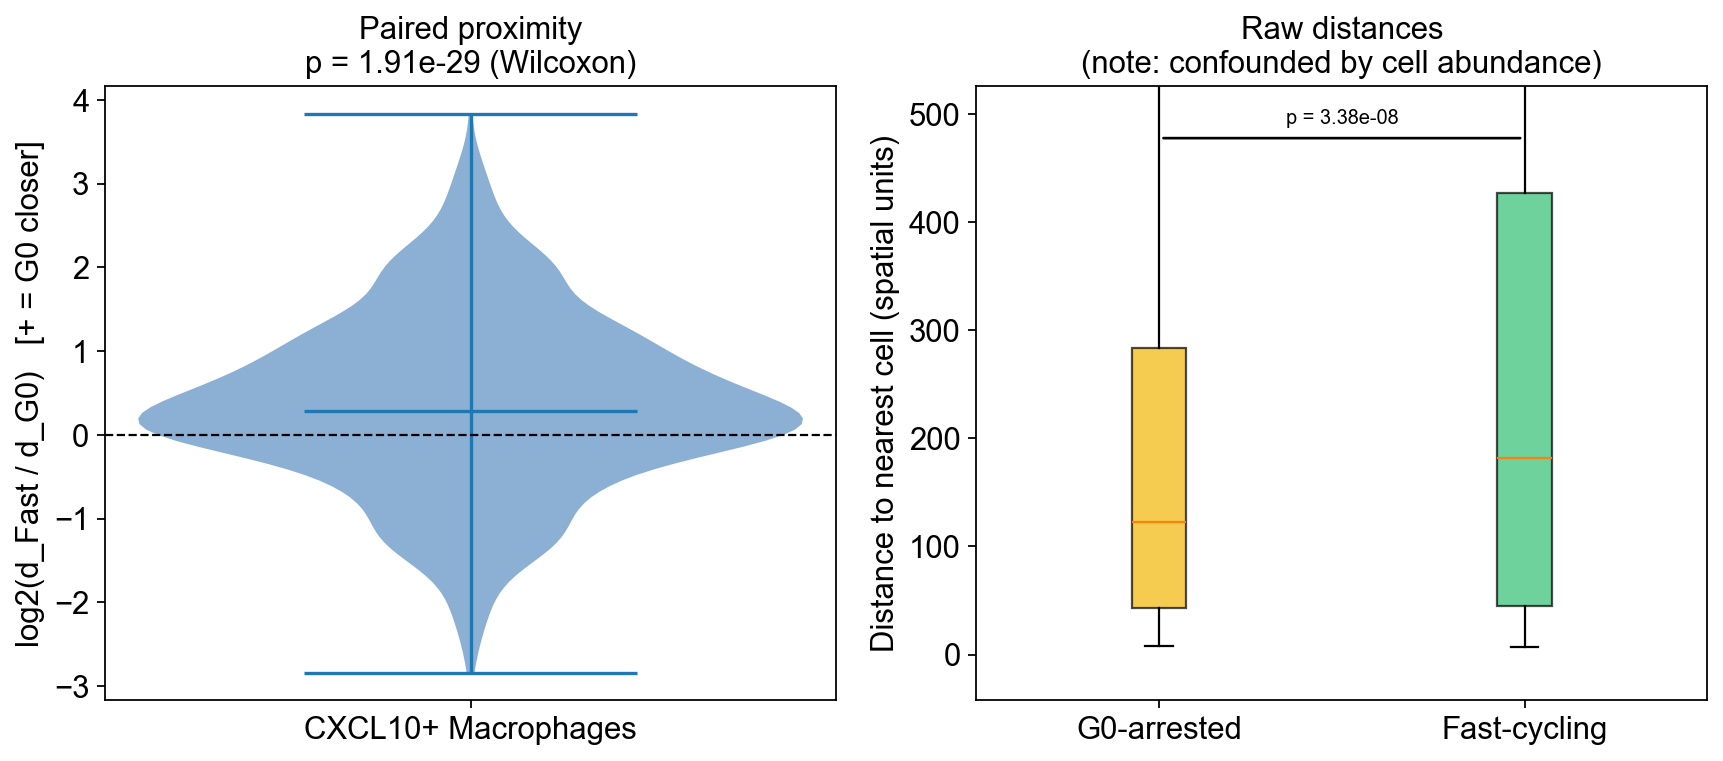

In [47]:
# Left: violin of log2(d_Fast/d_G0) — one value per CXCL10+ macrophage
# Right: raw distance boxplot with pairwise statistics
from scipy.stats import mannwhitneyu

fig, axes = plt.subplots(1, 2, figsize=(11, 5))

# --- Left: violin ---
vp = axes[0].violinplot([mac_log2_ratio], positions=[0], showmedians=True)
vp["bodies"][0].set_facecolor("#5A8FC3")
vp["bodies"][0].set_alpha(0.7)
axes[0].axhline(0, color="black", lw=1, linestyle="--")
axes[0].set_xticks([0])
axes[0].set_xticklabels(["CXCL10+ Macrophages"])
axes[0].set_ylabel("log2(d_Fast / d_G0)   [+ = G0 closer]")
axes[0].set_title(f"Paired proximity\np = {mac_pval_w:.2e} (Wilcoxon)")

# --- Right: raw distance boxplot ---
bp = axes[1].boxplot(
    [mac_to_g0_cell_dist, mac_to_fast_cell_dist],
    labels=["G0-arrested", "Fast-cycling"],
    patch_artist=True, showfliers=False
)
colors = ["#F2B705", "#2FBF71"]
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].set_ylabel("Distance to nearest cell (spatial units)")
axes[1].set_title("Raw distances\n(note: confounded by cell abundance)")

# --- Significance annotation on right plot ---
stat_mwu, pval_mwu = mannwhitneyu(mac_to_g0_cell_dist, mac_to_fast_cell_dist, alternative="two-sided")
if pval_mwu < 0.001:
    sig_label = f"p = {pval_mwu:.2e}"
elif pval_mwu < 0.05:
    sig_label = f"p = {pval_mwu:.3f}"
else:
    sig_label = "ns"

y_max = max(np.percentile(mac_to_g0_cell_dist, 75), np.percentile(mac_to_fast_cell_dist, 75))
y_bar = y_max * 1.12
y_text = y_bar * 1.02
axes[1].annotate(
    "", xy=(2, y_bar), xytext=(1, y_bar),
    arrowprops=dict(arrowstyle="-", color="black", lw=1.2),
)
axes[1].text(1.5, y_text, sig_label, ha="center", va="bottom", fontsize=9)
axes[1].set_ylim(top=y_text * 1.08)

plt.tight_layout()
plt.savefig(figure_dir + "xenium_cxcl10mac_proximity_summary.pdf", dpi=300, bbox_inches="tight")
plt.show()

### Abundance-Corrected Neighborhood Enrichment — CXCL10+ Macrophages

Raw distances (and log2 ratios) are still biased: fast-cycling cells cover more
of the tissue, so any macrophage will almost always find one nearby.  
The two approaches below **correct for global cell abundance**:

1. **Radius enrichment**: within radius *r* of each CXCL10 mac, is the *fraction*
   of G0 cells higher than the tissue-wide baseline? Enrichment > 1 means G0 is
   locally over-represented, regardless of total count.

2. **k-NN composition**: for each CXCL10 mac, take its *k* nearest tumor cells
   (G0 + Fast-cycling pooled). Is the fraction of G0 among those *k* cells higher
   than the global G0 baseline? Wilcoxon signed-rank tests whether the excess
   fraction is consistently > 0 across all macrophages.

In [48]:
# Pool G0-arrested and Fast-cycling tumor cells (shared across both analyses)
tumor_mask   = g0_mask | fast_mask
tumor_coords = adata.obsm["spatial"][tumor_mask.values]
tumor_labels = adata.obs.loc[tumor_mask, "cycling_state"].values

n_g0   = (tumor_labels == "G0-arrested").sum()
n_fast = (tumor_labels == "Fast-cycling").sum()
global_g0_frac = n_g0 / (n_g0 + n_fast)

print(f"G0-arrested  cells : {n_g0}")
print(f"Fast-cycling cells : {n_fast}")
print(f"Global G0 fraction (baseline): {global_g0_frac:.4f}  ({global_g0_frac*100:.1f}%)")

tumor_tree = cKDTree(tumor_coords)

G0-arrested  cells : 2374
Fast-cycling cells : 16662
Global G0 fraction (baseline): 0.1247  (12.5%)


In [49]:
# Radius-based neighborhood enrichment — CXCL10+ Macrophages (r = 100 µm)
from scipy.stats import wilcoxon

r = 100
enrichments = []
for coord in mac_hot_coords:
    idx = tumor_tree.query_ball_point(coord, r)
    if len(idx) < 3:
        enrichments.append(np.nan)
        continue
    obs_frac = (tumor_labels[idx] == "G0-arrested").mean()
    enrichments.append(obs_frac / global_g0_frac)
enrichments = np.array(enrichments)
mac_valid_enrich = enrichments[~np.isnan(enrichments)]

mac_stat_radius, mac_pval_radius = wilcoxon(mac_valid_enrich - 1, alternative="greater")
mac_radius_results = {r: {"enrichments": enrichments, "valid": mac_valid_enrich,
                          "median": np.median(mac_valid_enrich), "pval": mac_pval_radius}}

print(f"r={r}  |  n_macs={len(mac_valid_enrich)}  "
      f"|  median enrichment={np.median(mac_valid_enrich):.3f}  "
      f"|  p (G0 enriched) = {mac_pval_radius:.3e}")

r=100  |  n_macs=423  |  median enrichment=1.503  |  p (G0 enriched) = 1.238e-44


In [50]:
# Strategy 2: k-NN composition test — CXCL10+ Macrophages
from scipy.stats import wilcoxon

k = 100

mac_dists_knn, mac_idxs_knn = tumor_tree.query(mac_hot_coords, k=k)

mac_g0_fracs_knn = np.array(
    [(tumor_labels[row_idx] == "G0-arrested").mean() for row_idx in mac_idxs_knn]
)

mac_excess = mac_g0_fracs_knn - global_g0_frac

mac_stat_knn, mac_pval_knn = wilcoxon(mac_excess, alternative="greater")

print(f"k = {k} nearest tumour cells per CXCL10+ macrophage")
print(f"Global G0 baseline fraction     : {global_g0_frac*100:.2f}%")
print(f"Mean observed G0 fraction in kNN: {mac_g0_fracs_knn.mean()*100:.2f}%")
print(f"Median excess over baseline     : {np.median(mac_excess)*100:+.2f} pp")
print(f"% macs with G0 fraction > baseline : {(mac_excess > 0).mean()*100:.1f}%")
print(f"Wilcoxon signed-rank (excess > 0)  : stat={mac_stat_knn:.1f}, p={mac_pval_knn:.3e}")

k = 100 nearest tumour cells per CXCL10+ macrophage
Global G0 baseline fraction     : 12.47%
Mean observed G0 fraction in kNN: 35.91%
Median excess over baseline     : +17.53 pp
% macs with G0 fraction > baseline : 85.9%
Wilcoxon signed-rank (excess > 0)  : stat=595886.0, p=5.356e-159


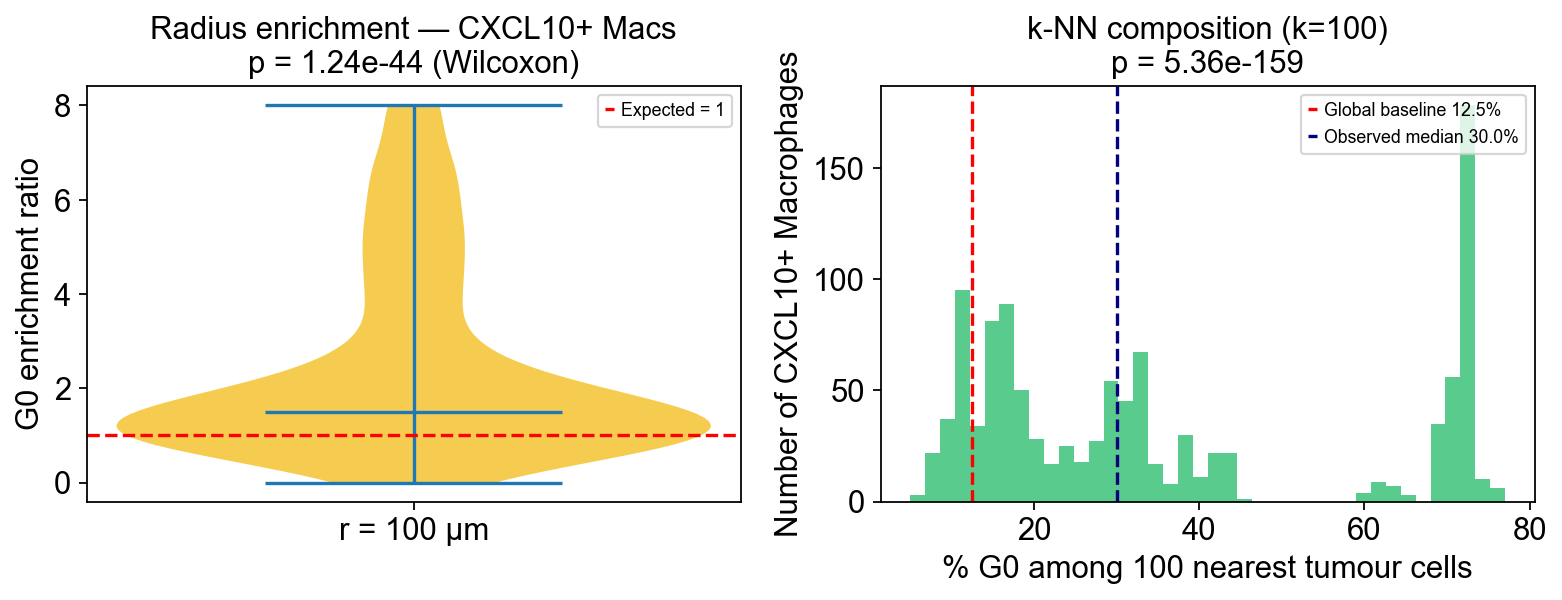

In [51]:
# Visualise abundance-corrected enrichment results — CXCL10+ Macrophages
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# --- Left: violin of enrichment ratio (r=100) ---
vp = axes[0].violinplot([mac_valid_enrich], positions=[0], showmedians=True)
vp["bodies"][0].set_facecolor("#F2B705")
vp["bodies"][0].set_alpha(0.7)
axes[0].axhline(1, color="red", lw=1.5, linestyle="--", label="Expected = 1")
axes[0].set_xticks([0])
axes[0].set_xticklabels([f"r = {r} µm"])
axes[0].set_ylabel("G0 enrichment ratio")
axes[0].set_title(f"Radius enrichment — CXCL10+ Macs\np = {mac_pval_radius:.2e} (Wilcoxon)")
axes[0].legend(fontsize=8)

# --- Right: histogram of k-NN G0 fraction ---
axes[1].hist(mac_g0_fracs_knn * 100, bins=40, color="#2FBF71", edgecolor="none", alpha=0.8)
axes[1].axvline(global_g0_frac * 100, color="red", lw=1.5, linestyle="--",
                label=f"Global baseline {global_g0_frac*100:.1f}%")
axes[1].axvline(np.median(mac_g0_fracs_knn) * 100, color="navy", lw=1.5, linestyle="--",
                label=f"Observed median {np.median(mac_g0_fracs_knn)*100:.1f}%")
axes[1].set_xlabel(f"% G0 among {k} nearest tumour cells")
axes[1].set_ylabel("Number of CXCL10+ Macrophages")
axes[1].set_title(f"k-NN composition (k={k})\np = {mac_pval_knn:.2e}")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(figure_dir + "xenium_cxcl10mac_abundance_corrected_enrichment.pdf",
            dpi=300, bbox_inches="tight")
plt.show()

## myCAF Analysis

### Generate myCAF Signature

In [52]:
# Reload adata_sc for myCAF analysis
adata_sc = sc.read_h5ad("data/Wu_etal_2021_BRCA_scRNASeq_processed_with_quiescence_scores.h5ad")

In [53]:
adata_sc.X = adata_sc.layers["counts"].copy()

In [54]:
adata_sc.obs["group"] = np.where(
    adata_sc.obs["cell_type"] == "CAFs myCAF-like",
    "myCAF",
    "Rest",
)

# Create pseudo-replicates
rng = np.random.default_rng(0)

rep_labels = []
for grp in ["myCAF", "Rest"]:
    mask = adata_sc.obs["group"] == grp
    n = mask.sum()
    assignments = rng.integers(0, replicate, size=n)
    rep_labels.append(
        pd.Series(
            [f"{grp}_rep{i}" for i in assignments],
            index=adata_sc.obs_names[mask],
        )
    )
adata_sc.obs["pseudo_rep"] = pd.concat(rep_labels)

# Aggregate raw counts per pseudo-replicate
counts_mat = adata_sc.raw.X if adata_sc.raw is not None else adata_sc.X

if issparse(counts_mat):
    counts_mat = counts_mat.toarray()

counts_df = pd.DataFrame(
    counts_mat,
    index=adata_sc.obs_names,
    columns=(adata_sc.raw.var_names if adata_sc.raw is not None else adata_sc.var_names),
)
counts_df["pseudo_rep"] = adata_sc.obs["pseudo_rep"]

pseudobulk = counts_df.groupby("pseudo_rep").sum()

# Build sample metadata
sample_meta = pd.DataFrame({"pseudo_rep": pseudobulk.index})
sample_meta["group"] = sample_meta["pseudo_rep"].str.rsplit("_rep", n=1).str[0]
sample_meta = sample_meta.set_index("pseudo_rep")

# Pre-filter low-count genes
gene_keep = pseudobulk.columns[pseudobulk.sum(axis=0) >= 10]
pseudobulk = pseudobulk[gene_keep]

dds = DeseqDataSet(
    counts=pseudobulk,
    metadata=sample_meta,
    design="~group",
    ref_level=["group", "Rest"],
)

dds.deseq2()

stat = DeseqStats(dds, contrast=["group", "myCAF", "Rest"])
stat.summary()

results = stat.results_df.copy()

# Filter for upregulated genes in myCAF vs Rest
up = results[(results["padj"] < 0.01) & (results["log2FoldChange"] > 2)].sort_values(
    "log2FoldChange", ascending=False
)

Fitting size factors...
... done in 0.01 seconds.



Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...
... done in 2.70 seconds.

Fitting dispersion trend curve...
... done in 0.42 seconds.

Fitting MAP dispersions...
... done in 2.62 seconds.

Fitting LFCs...
... done in 4.03 seconds.

Calculating cook's distance...
... done in 0.02 seconds.

Replacing 0 outlier genes.

Running Wald tests...


Log2 fold change & Wald test p-value: group myCAF vs Rest
                 baseMean  log2FoldChange     lfcSE       stat        pvalue  \
RP11-34P13.7    10.594594        0.268483  0.566334   0.474072  6.354485e-01   
FO538757.3       4.804999       -2.121769  1.405163  -1.509981  1.310483e-01   
FO538757.2     772.532113       -0.048458  0.076187  -0.636035  5.247533e-01   
AP006222.2     569.577969        1.135715  0.079426  14.299111  2.216212e-46   
RP4-669L17.10   29.562631        0.583475  0.340899   1.711576  8.697475e-02   
...                   ...             ...       ...        ...           ...   
RP11-503D12.1    4.243544       -3.187807  1.949966  -1.634801  1.020907e-01   
AL121578.2       2.413378       -2.374634  1.953258  -1.215729  2.240880e-01   
CXADRP3          5.980904       -3.681759  1.947262  -1.890736  5.865956e-02   
RP11-5P18.5      1.310709       -1.490068  1.981432  -0.752016  4.520415e-01   
LINC00550        0.785048       -0.750944  1.970540  -0.381086

... done in 2.44 seconds.



In [55]:
print(f"Upregulated genes in myCAF: {len(up)}")
gene_set_caf = up.head(500).index.tolist()

Upregulated genes in myCAF: 1614


### Score Xenium - myCAFs

In [56]:
adata_caf = adata[adata.obs["cell_type"].str.contains("Stromal")].copy()
adata_caf.X = adata_caf.layers["counts"].copy()
sc.pp.filter_genes(adata_caf, min_cells=1)
sc.pp.normalize_total(adata_caf, target_sum=1e4)
adata_caf.X = np.log1p(adata_caf.X)

In [57]:
gene_set_caf = [g for g in gene_set_caf if g in adata_caf.var_names]
print(f"Available genes: {len(gene_set_caf)}")

Available genes: 15


In [58]:
em.tl.score(adata_caf, gene_set_caf, score_key="myCAF")

Scoring signatures: 100%|██████████| 1/1 [00:02<00:00,  2.08s/it]


In [59]:
adata.obs["myCAF_score"] = np.nan
adata.obs.loc[adata_caf.obs_names, "myCAF_score"] = adata_caf.obs["myCAF_score"]

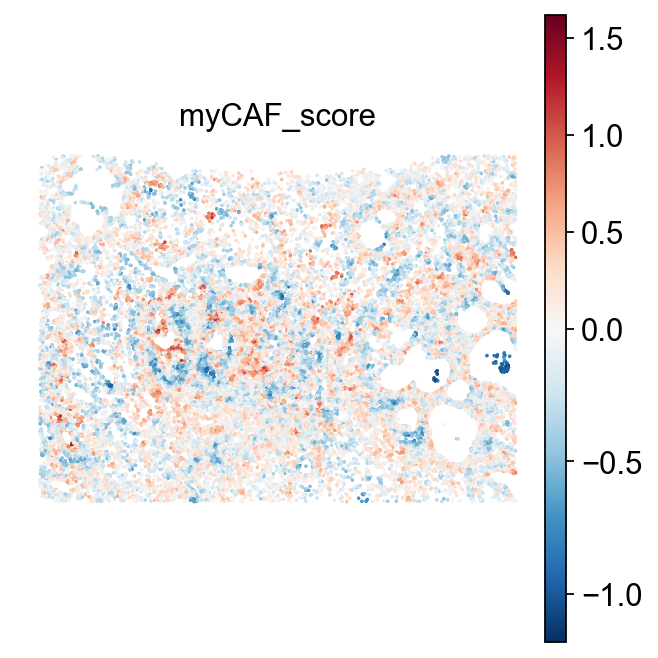

In [60]:
sq.pl.spatial_scatter(
    adata[adata.obs["cell_type"].str.contains("Stromal")],
    shape=None,
    color=["myCAF_score"],
    size=1,
    vcenter=0,
    cmap="RdBu_r",
    save=figure_dir + "xenium_mycaf_score.pdf",
)

### Hotspot Analysis - myCAFs

In [61]:
# Scale myCAF_score
scaler = MinMaxScaler()
adata.obs["myCAF_score"] = scaler.fit_transform(adata.obs[["myCAF_score"]])

In [62]:
# batch and array_row/col already set from CXCL10 hotspot setup
adata = sp.create_hotspots(
    adata,
    column_name="myCAF_score",
    neighbours_parameters=6,
    relative_to_batch=True,
    filter_columns="cell_type",
    filter_value="Stromal",
)

In [63]:
adata_subset_caf = adata[
    (adata.obs["cycling_state"].isin(["G0-arrested", "Fast-cycling"]))
    | (adata.obs["cell_type"] == "Stromal")
].copy()

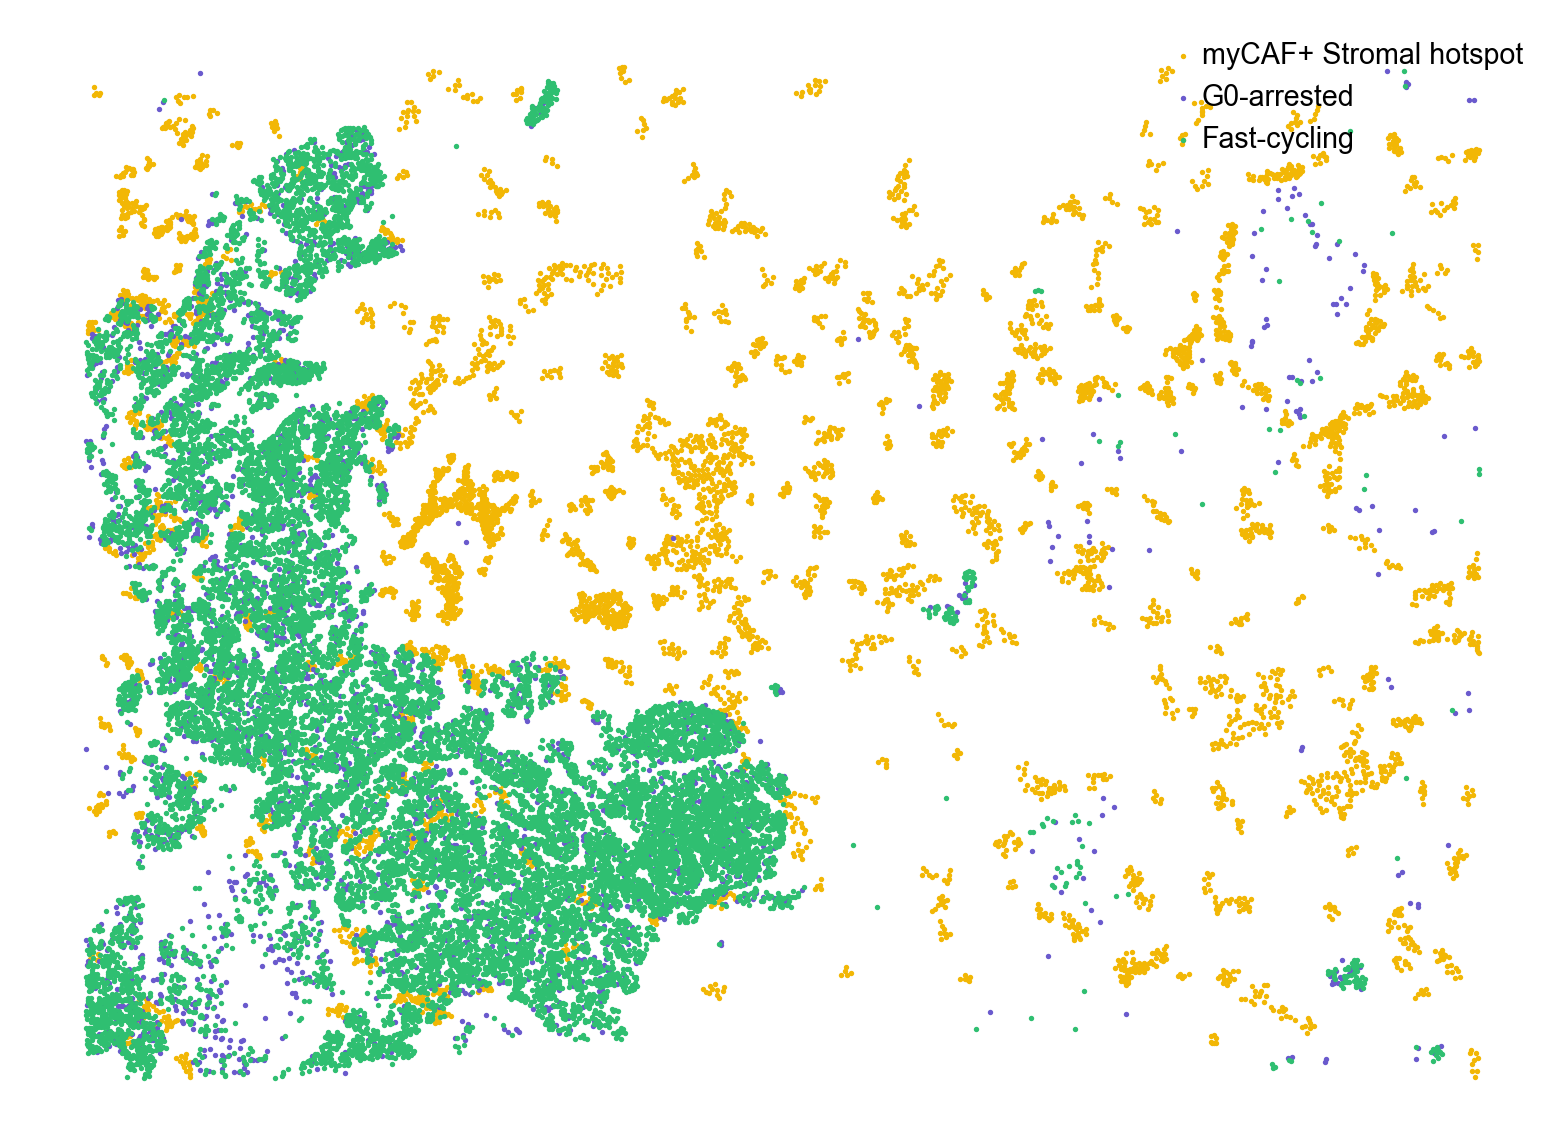

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [64]:
plot_overlaid_spatial(
    adata_subset_caf,
    layers=[
        {
            "mask": (adata_subset_caf.obs["myCAF_score_hot"].notna()).values,
            "color": "#F2B705",
            "label": "myCAF+ Stromal hotspot",
            "size": 2,
        },
        {
            "mask": (adata_subset_caf.obs["cycling_state"] == "G0-arrested").values,
            "color": "#6A5ACD",
            "label": "G0-arrested",
            "size": 2,
        },
        {
            "mask": (adata_subset_caf.obs["cycling_state"] == "Fast-cycling").values,
            "color": "#2FBF71",
            "label": "Fast-cycling",
            "size": 2,
        },
    ],
    background_color="white",
    figsize=(10, 10),
    save=figure_dir + "xenium_g0_fast_mycaf_stromal.pdf",
)

### Distance Quantification: myCAFs to G0-arrested and Fast-cycling cells

In [65]:
# Get spatial coordinates for myCAF hotspots
# g0_mask, fast_mask, g0_coords, fast_coords already defined above
caf_hot_mask = adata.obs["myCAF_score_hot"].notna()
caf_hot_coords = adata.obsm["spatial"][caf_hot_mask.values]

print(f"G0-arrested cells: {len(g0_coords)}")
print(f"Fast-cycling cells: {len(fast_coords)}")
print(f"myCAF+ Stromal hotspot cells: {len(caf_hot_coords)}")

G0-arrested cells: 2374
Fast-cycling cells: 16662
myCAF+ Stromal hotspot cells: 6112


In [66]:
# Cluster myCAF+ Stromal hotspots using DBSCAN
# (g0_labels and fast_labels reused from CXCL10 section)
caf_clustering = DBSCAN(eps=50, min_samples=5).fit(caf_hot_coords)
caf_labels = caf_clustering.labels_

print(f"G0 clusters found: {len(set(g0_labels)) - (1 if -1 in g0_labels else 0)}")
print(f"Fast-cycling clusters found: {len(set(fast_labels)) - (1 if -1 in fast_labels else 0)}")
print(f"myCAF+ Stromal hotspot clusters found: {len(set(caf_labels)) - (1 if -1 in caf_labels else 0)}")

G0 clusters found: 2
Fast-cycling clusters found: 43
myCAF+ Stromal hotspot clusters found: 319


In [67]:
# Calculate centroids for myCAF hotspot clusters
# (g0_centroids and fast_centroids reused from CXCL10 section)
caf_centroids = get_cluster_centroids(caf_hot_coords, caf_labels)

print(f"G0 cluster centroids: {len(g0_centroids)}")
print(f"Fast-cycling cluster centroids: {len(fast_centroids)}")
print(f"myCAF+ Stromal hotspot clusters: {len(caf_centroids)}")

G0 cluster centroids: 2
Fast-cycling cluster centroids: 43
myCAF+ Stromal hotspot clusters: 319


In [68]:
# Centroid-to-centroid distances: myCAF+ Stromal hotspot clusters → G0 and Fast-cycling clusters
if len(caf_centroids) > 0 and len(g0_centroids) > 0:
    caf_centroid_arr = np.array(list(caf_centroids.values()))
    g0_centroid_arr = np.array(list(g0_centroids.values()))

    caf_to_g0_dists = cdist(caf_centroid_arr, g0_centroid_arr)
    caf_to_g0_min = caf_to_g0_dists.min(axis=1)

    print("myCAF+ Stromal hotspot to G0-arrested cluster distances (centroid-to-centroid):")
    print(f"  Mean minimum distance: {caf_to_g0_min.mean():.2f}")
    print(f"  Median minimum distance: {np.median(caf_to_g0_min):.2f}")
    print(f"  Std: {caf_to_g0_min.std():.2f}")
    print(f"  Range: [{caf_to_g0_min.min():.2f}, {caf_to_g0_min.max():.2f}]")

if len(caf_centroids) > 0 and len(fast_centroids) > 0:
    caf_centroid_arr = np.array(list(caf_centroids.values()))
    fast_centroid_arr = np.array(list(fast_centroids.values()))

    caf_to_fast_dists = cdist(caf_centroid_arr, fast_centroid_arr)
    caf_to_fast_min = caf_to_fast_dists.min(axis=1)

    print("myCAF+ Stromal hotspot to Fast-cycling cluster distances (centroid-to-centroid):")
    print(f"  Mean minimum distance: {caf_to_fast_min.mean():.2f}")
    print(f"  Median minimum distance: {np.median(caf_to_fast_min):.2f}")
    print(f"  Std: {caf_to_fast_min.std():.2f}")
    print(f"  Range: [{caf_to_fast_min.min():.2f}, {caf_to_fast_min.max():.2f}]")

myCAF+ Stromal hotspot to G0-arrested cluster distances (centroid-to-centroid):
  Mean minimum distance: 3203.87
  Median minimum distance: 2914.06
  Std: 1782.13
  Range: [113.99, 7143.44]
myCAF+ Stromal hotspot to Fast-cycling cluster distances (centroid-to-centroid):
  Mean minimum distance: 995.41
  Median minimum distance: 798.68
  Std: 776.42
  Range: [47.29, 3550.35]


### Paired log-ratio analysis — abundance-robust proximity test

Same approach as for CXCL10+ Macrophages: for each myCAF+ Stromal hotspot cell
we compute BOTH nearest-G0 and nearest-Fast-cycling distances simultaneously.

`log2_ratio = log2(d_Fast / d_G0)`
- `> 0` → G0 cell is the closer population
- `< 0` → Fast-cycling cell is closer

In [69]:
# Cell-level analysis: distance from each myCAF+ Stromal hotspot to nearest G0 / Fast-cycling cell
# g0_tree and fast_tree already built from CXCL10 section

# Distance from each myCAF+ Stromal hotspot cell to nearest G0-arrested cell
caf_to_g0_cell_dist,   _ = g0_tree.query(caf_hot_coords,   k=1)

# Distance from each myCAF+ Stromal hotspot cell to nearest Fast-cycling cell
caf_to_fast_cell_dist, _ = fast_tree.query(caf_hot_coords, k=1)

print("myCAF+ Stromal hotspot to nearest G0-arrested cell:")
print(f"  Mean distance  : {caf_to_g0_cell_dist.mean():.2f}")
print(f"  Median distance: {np.median(caf_to_g0_cell_dist):.2f}")
print(f"  Std            : {caf_to_g0_cell_dist.std():.2f}")

print("\nmyCAF+ Stromal hotspot to nearest Fast-cycling cell:")
print(f"  Mean distance  : {caf_to_fast_cell_dist.mean():.2f}")
print(f"  Median distance: {np.median(caf_to_fast_cell_dist):.2f}")
print(f"  Std            : {caf_to_fast_cell_dist.std():.2f}")

# Paired log2 ratio
caf_log2_ratio = np.log2(caf_to_fast_cell_dist / caf_to_g0_cell_dist)

print(f"\nmyCAF+ Stromal hotspots analysed     : {len(caf_log2_ratio)}")
print(f"% where G0 is closer             : {(caf_log2_ratio > 0).mean()*100:.1f}%")
print(f"% where Fast-cycling is closer   : {(caf_log2_ratio < 0).mean()*100:.1f}%")
print(f"Median log2(d_Fast/d_G0)         : {np.median(caf_log2_ratio):.3f}")

myCAF+ Stromal hotspot to nearest G0-arrested cell:
  Mean distance  : 286.73
  Median distance: 243.75
  Std            : 219.97

myCAF+ Stromal hotspot to nearest Fast-cycling cell:
  Mean distance  : 428.42
  Median distance: 346.32
  Std            : 359.87

myCAF+ Stromal hotspots analysed     : 6112
% where G0 is closer             : 60.9%
% where Fast-cycling is closer   : 39.1%
Median log2(d_Fast/d_G0)         : 0.146


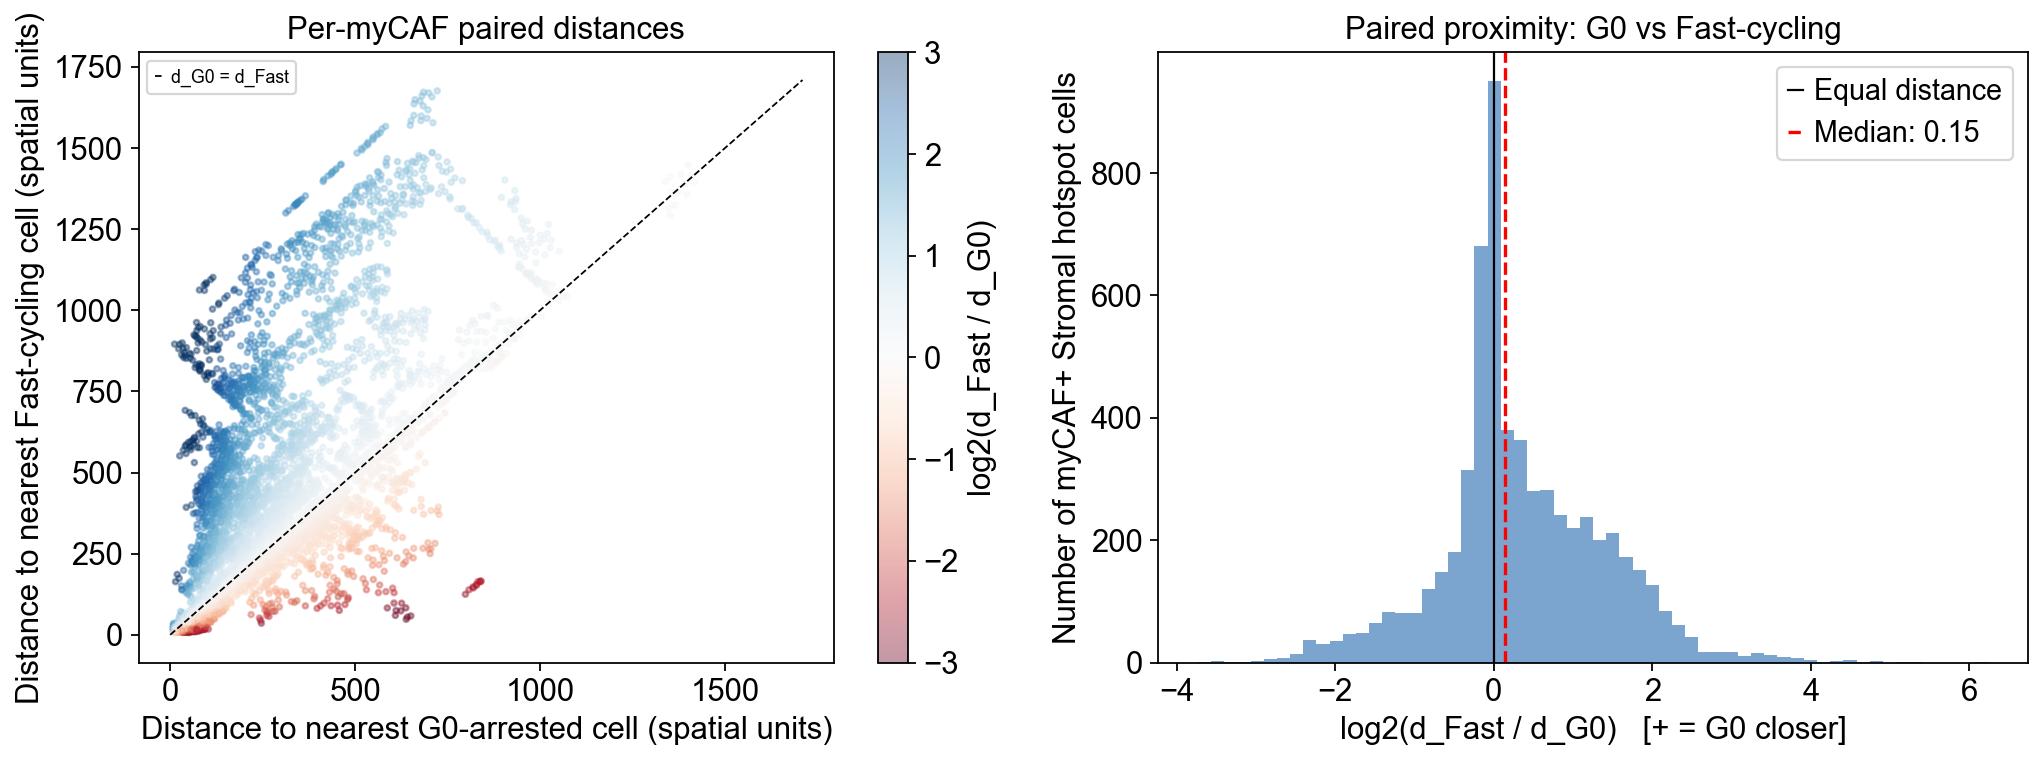

In [70]:
# Paired scatter: d_G0 vs d_Fast per myCAF+ Stromal hotspot, coloured by log2 ratio
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Left: scatter d_G0 vs d_Fast ---
sc_plot = axes[0].scatter(
    caf_to_g0_cell_dist, caf_to_fast_cell_dist,
    c=caf_log2_ratio, cmap="RdBu", alpha=0.4, s=6, vmin=-3, vmax=3
)
lim = max(caf_to_g0_cell_dist.max(), caf_to_fast_cell_dist.max()) * 1.02
axes[0].plot([0, lim], [0, lim], "k--", lw=0.8, label="d_G0 = d_Fast")
axes[0].set_xlabel("Distance to nearest G0-arrested cell (spatial units)")
axes[0].set_ylabel("Distance to nearest Fast-cycling cell (spatial units)")
axes[0].set_title("Per-myCAF paired distances")
axes[0].legend(fontsize=8)
plt.colorbar(sc_plot, ax=axes[0], label="log2(d_Fast / d_G0)")

# --- Right: histogram of log2 ratio ---
axes[1].hist(caf_log2_ratio, bins=60, color="#5A8FC3", edgecolor="none", alpha=0.8)
axes[1].axvline(0, color="black", lw=1, linestyle="-", label="Equal distance")
axes[1].axvline(np.median(caf_log2_ratio), color="red", lw=1.5, linestyle="--",
                label=f"Median: {np.median(caf_log2_ratio):.2f}")
axes[1].set_xlabel("log2(d_Fast / d_G0)   [+ = G0 closer]")
axes[1].set_ylabel("Number of myCAF+ Stromal hotspot cells")
axes[1].set_title("Paired proximity: G0 vs Fast-cycling")
axes[1].legend()

plt.tight_layout()
plt.savefig(figure_dir + "xenium_mycaf_paired_proximity.pdf", dpi=300, bbox_inches="tight")
plt.show()

In [71]:
# Wilcoxon signed-rank test on log2(d_Fast / d_G0)
# H0: median log2 ratio = 0  (G0 and Fast-cycling are equidistant)

caf_stat_w, caf_pval_w = wilcoxon(caf_log2_ratio, alternative="two-sided")
caf_stat_greater, caf_pval_greater = wilcoxon(caf_log2_ratio, alternative="greater")

print("Wilcoxon signed-rank test on log2(d_Fast / d_G0) — myCAF+ Stromal hotspots:")
print(f"  Two-sided                             : stat={caf_stat_w:.2f}, p={caf_pval_w:.2e}")
print(f"  One-sided (H1: G0 closer, ratio > 0) : stat={caf_stat_greater:.2f}, p={caf_pval_greater:.2e}")
print(f"\n  Median log2 ratio : {np.median(caf_log2_ratio):.4f}")
print(f"  % cafs where G0 is closer   : {(caf_log2_ratio > 0).mean()*100:.1f}%")
print(f"  % cafs where Fast is closer : {(caf_log2_ratio < 0).mean()*100:.1f}%")

Wilcoxon signed-rank test on log2(d_Fast / d_G0) — myCAF+ Stromal hotspots:
  Two-sided                             : stat=6068908.00, p=2.46e-124
  One-sided (H1: G0 closer, ratio > 0) : stat=12612420.00, p=1.23e-124

  Median log2 ratio : 0.1458
  % cafs where G0 is closer   : 60.9%
  % cafs where Fast is closer : 39.1%


In [72]:
# Summary dataframe
caf_distance_summary = pd.DataFrame({
    "Metric": [
        "myCAF to G0 (median)", "myCAF to G0 (mean)",
        "myCAF to Fast (median)", "myCAF to Fast (mean)",
        "log2 ratio (median)", "% cafs G0 closer",
        "Wilcoxon p (two-sided)",
    ],
    "Value": [
        np.median(caf_to_g0_cell_dist), caf_to_g0_cell_dist.mean(),
        np.median(caf_to_fast_cell_dist), caf_to_fast_cell_dist.mean(),
        np.median(caf_log2_ratio), (caf_log2_ratio > 0).mean() * 100,
        caf_pval_w,
    ],
})
caf_distance_summary.to_csv(processed_data + "mycaf_paired_distance_summary.csv", index=False)
display(caf_distance_summary)

# Store in adata.obs for myCAF+ Stromal hotspot cells
caf_hot_cell_names = adata.obs_names[caf_hot_mask.values]
adata.obs["caf_dist_to_g0"]           = np.nan
adata.obs["caf_dist_to_fast_cycling"] = np.nan
adata.obs["caf_log2_proximity_ratio"] = np.nan
adata.obs.loc[caf_hot_cell_names, "caf_dist_to_g0"]           = caf_to_g0_cell_dist
adata.obs.loc[caf_hot_cell_names, "caf_dist_to_fast_cycling"] = caf_to_fast_cell_dist
adata.obs.loc[caf_hot_cell_names, "caf_log2_proximity_ratio"] = caf_log2_ratio

,Metric,Value
0,myCAF to G0 (median),2.437507e+02
1,myCAF to G0 (mean),2.867304e+02
2,myCAF to Fast (median),3.463182e+02
3,myCAF to Fast (mean),4.284223e+02
4,log2 ratio (median),1.457508e-01
5,% cafs G0 closer,6.091296e+01
6,Wilcoxon p (two-sided),2.460095e-124


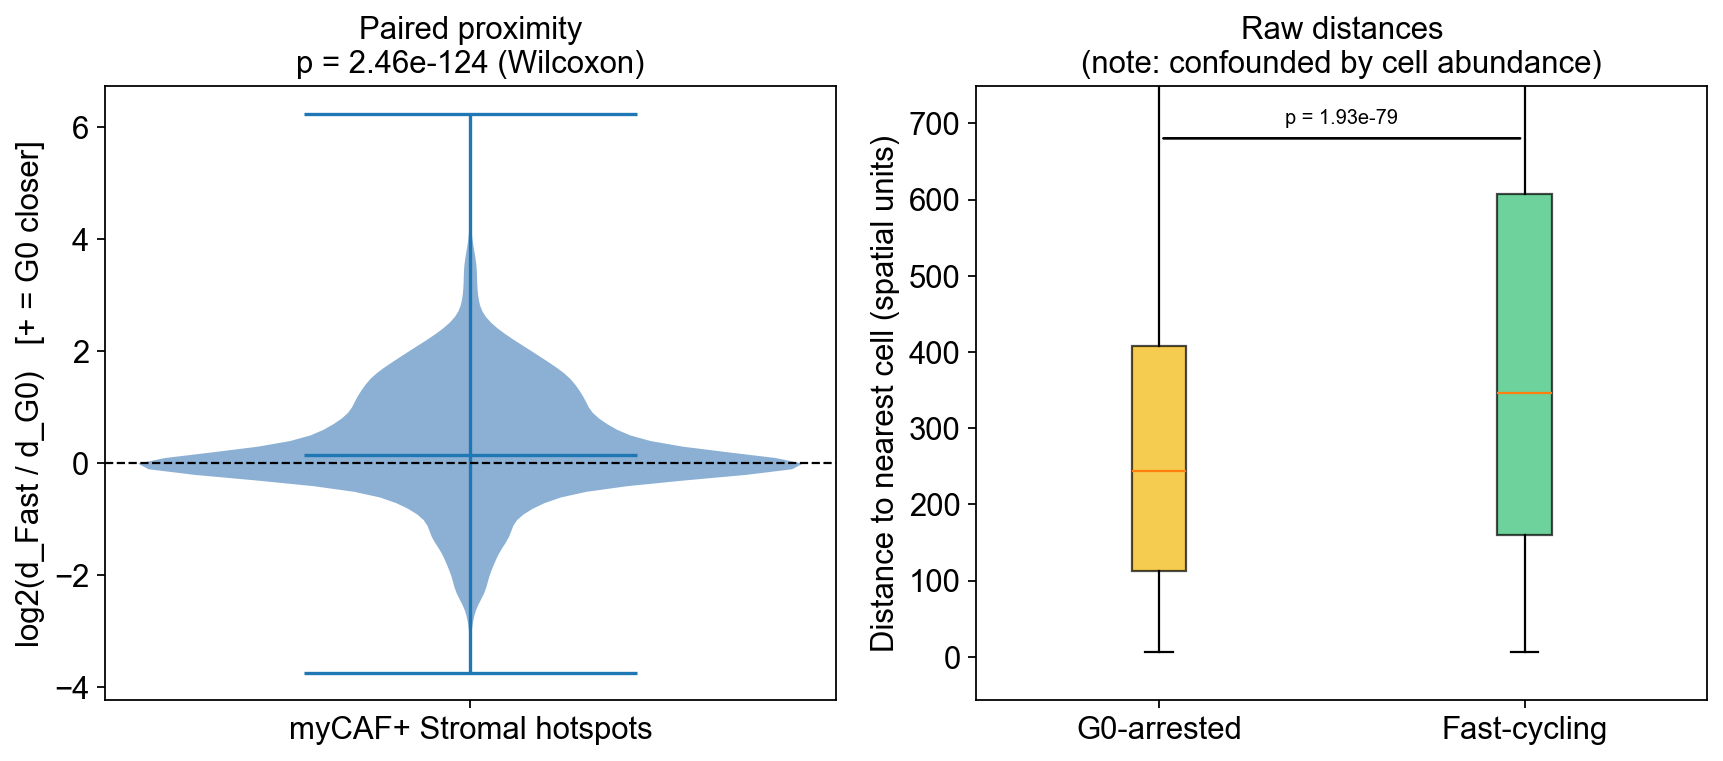

In [73]:
# Left: violin of log2(d_Fast/d_G0) — one value per myCAF+ Stromal hotspot
# Right: raw distance boxplot with pairwise statistics

fig, axes = plt.subplots(1, 2, figsize=(11, 5))

# --- Left: violin ---
vp = axes[0].violinplot([caf_log2_ratio], positions=[0], showmedians=True)
vp["bodies"][0].set_facecolor("#5A8FC3")
vp["bodies"][0].set_alpha(0.7)
axes[0].axhline(0, color="black", lw=1, linestyle="--")
axes[0].set_xticks([0])
axes[0].set_xticklabels(["myCAF+ Stromal hotspots"])
axes[0].set_ylabel("log2(d_Fast / d_G0)   [+ = G0 closer]")
axes[0].set_title(f"Paired proximity\np = {caf_pval_w:.2e} (Wilcoxon)")

# --- Right: raw distance boxplot ---
bp = axes[1].boxplot(
    [caf_to_g0_cell_dist, caf_to_fast_cell_dist],
    labels=["G0-arrested", "Fast-cycling"],
    patch_artist=True, showfliers=False
)
colors = ["#F2B705", "#2FBF71"]
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].set_ylabel("Distance to nearest cell (spatial units)")
axes[1].set_title("Raw distances\n(note: confounded by cell abundance)")

# --- Significance annotation on right plot ---
stat_mwu, pval_mwu = mannwhitneyu(caf_to_g0_cell_dist, caf_to_fast_cell_dist, alternative="two-sided")
if pval_mwu < 0.001:
    sig_label = f"p = {pval_mwu:.2e}"
elif pval_mwu < 0.05:
    sig_label = f"p = {pval_mwu:.3f}"
else:
    sig_label = "ns"

y_max = max(np.percentile(caf_to_g0_cell_dist, 75), np.percentile(caf_to_fast_cell_dist, 75))
y_bar = y_max * 1.12
y_text = y_bar * 1.02
axes[1].annotate(
    "", xy=(2, y_bar), xytext=(1, y_bar),
    arrowprops=dict(arrowstyle="-", color="black", lw=1.2),
)
axes[1].text(1.5, y_text, sig_label, ha="center", va="bottom", fontsize=9)
axes[1].set_ylim(top=y_text * 1.08)

plt.tight_layout()
plt.savefig(figure_dir + "xenium_mycaf_proximity_summary.pdf", dpi=300, bbox_inches="tight")
plt.show()

### Abundance-Corrected Neighborhood Enrichment — myCAFs

Same two strategies as for CXCL10+ Macrophages, applied to myCAF+ Stromal hotspot cells.
The global G0 baseline (`global_g0_frac`) and tumor KD-tree (`tumor_tree`) are reused
from the CXCL10 section as they reflect the same tissue.

In [74]:
# Radius-based neighborhood enrichment — myCAFs (r = 100 µm)
caf_enrichments = []
for coord in caf_hot_coords:
    idx = tumor_tree.query_ball_point(coord, r)
    if len(idx) < 3:
        caf_enrichments.append(np.nan)
        continue
    obs_frac = (tumor_labels[idx] == "G0-arrested").mean()
    caf_enrichments.append(obs_frac / global_g0_frac)
caf_enrichments = np.array(caf_enrichments)
caf_valid_enrich = caf_enrichments[~np.isnan(caf_enrichments)]

caf_stat_radius, caf_pval_radius = wilcoxon(caf_valid_enrich - 1, alternative="greater")
caf_radius_results = {r: {"enrichments": caf_enrichments, "valid": caf_valid_enrich,
                          "median": np.median(caf_valid_enrich), "pval": caf_pval_radius}}

print(f"r={r}  |  n_cafs={len(caf_valid_enrich)}  "
      f"|  median enrichment={np.median(caf_valid_enrich):.3f}  "
      f"|  p (G0 enriched) = {caf_pval_radius:.3e}")

r=100  |  n_cafs=1144  |  median enrichment=1.237  |  p (G0 enriched) = 4.339e-36


In [75]:
# Strategy 2: k-NN composition test — myCAFs
caf_dists_knn, caf_idxs_knn = tumor_tree.query(caf_hot_coords, k=k)

caf_g0_fracs_knn = np.array(
    [(tumor_labels[row_idx] == "G0-arrested").mean() for row_idx in caf_idxs_knn]
)

caf_excess = caf_g0_fracs_knn - global_g0_frac

caf_stat_knn, caf_pval_knn = wilcoxon(caf_excess, alternative="greater")

print(f"k = {k} nearest tumour cells per myCAF+ Stromal hotspot")
print(f"Global G0 baseline fraction     : {global_g0_frac*100:.2f}%")
print(f"Mean observed G0 fraction in kNN: {caf_g0_fracs_knn.mean()*100:.2f}%")
print(f"Median excess over baseline     : {np.median(caf_excess)*100:+.2f} pp")
print(f"% cafs with G0 fraction > baseline : {(caf_excess > 0).mean()*100:.1f}%")
print(f"Wilcoxon signed-rank (excess > 0)  : stat={caf_stat_knn:.1f}, p={caf_pval_knn:.3e}")

k = 100 nearest tumour cells per myCAF+ Stromal hotspot
Global G0 baseline fraction     : 12.47%
Mean observed G0 fraction in kNN: 30.87%
Median excess over baseline     : +10.53 pp
% cafs with G0 fraction > baseline : 86.0%
Wilcoxon signed-rank (excess > 0)  : stat=17705417.0, p=0.000e+00


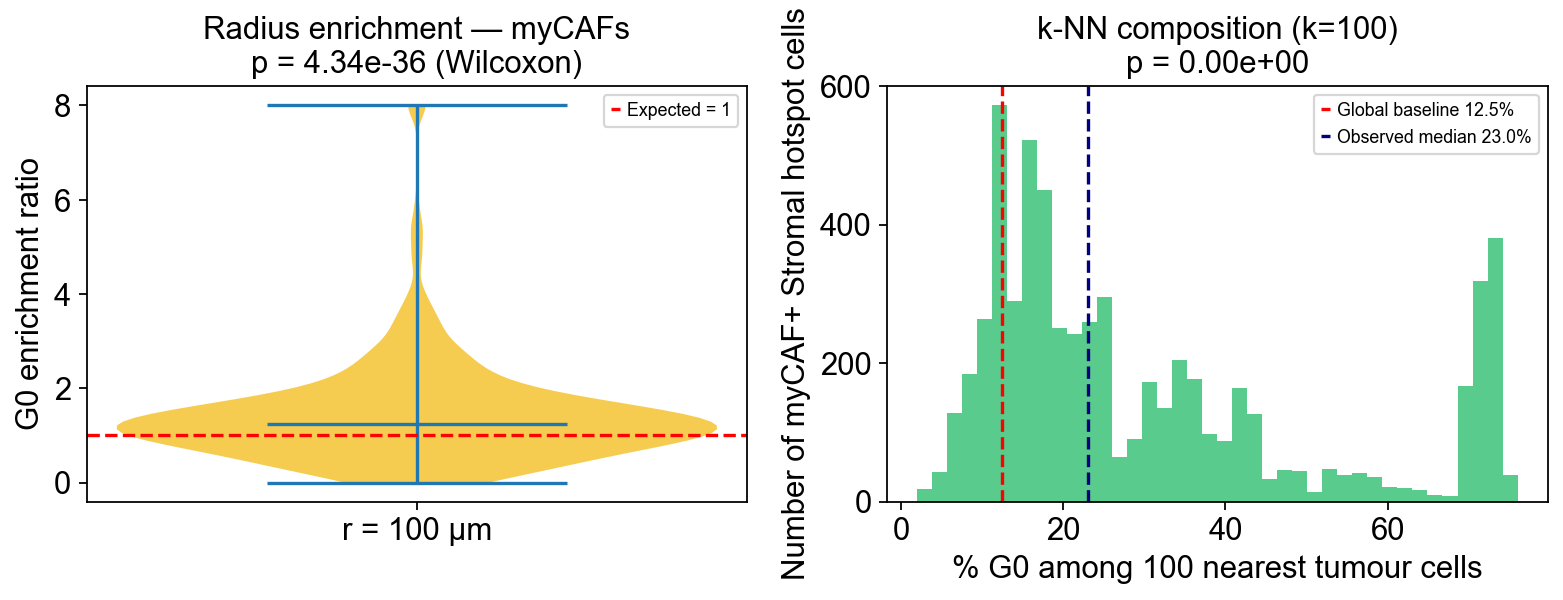

In [76]:
# Visualise abundance-corrected enrichment results — myCAFs
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# --- Left: violin of enrichment ratio (r=100) ---
vp = axes[0].violinplot([caf_valid_enrich], positions=[0], showmedians=True)
vp["bodies"][0].set_facecolor("#F2B705")
vp["bodies"][0].set_alpha(0.7)
axes[0].axhline(1, color="red", lw=1.5, linestyle="--", label="Expected = 1")
axes[0].set_xticks([0])
axes[0].set_xticklabels([f"r = {r} µm"])
axes[0].set_ylabel("G0 enrichment ratio")
axes[0].set_title(f"Radius enrichment — myCAFs\np = {caf_pval_radius:.2e} (Wilcoxon)")
axes[0].legend(fontsize=8)

# --- Right: histogram of k-NN G0 fraction ---
axes[1].hist(caf_g0_fracs_knn * 100, bins=40, color="#2FBF71", edgecolor="none", alpha=0.8)
axes[1].axvline(global_g0_frac * 100, color="red", lw=1.5, linestyle="--",
                label=f"Global baseline {global_g0_frac*100:.1f}%")
axes[1].axvline(np.median(caf_g0_fracs_knn) * 100, color="navy", lw=1.5, linestyle="--",
                label=f"Observed median {np.median(caf_g0_fracs_knn)*100:.1f}%")
axes[1].set_xlabel(f"% G0 among {k} nearest tumour cells")
axes[1].set_ylabel("Number of myCAF+ Stromal hotspot cells")
axes[1].set_title(f"k-NN composition (k={k})\np = {caf_pval_knn:.2e}")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(figure_dir + "xenium_mycaf_abundance_corrected_enrichment.pdf",
            dpi=300, bbox_inches="tight")
plt.show()

## Combined Comparison: CXCL10+ Macrophages vs myCAFs

Head-to-head summary of spatial proximity and G0 enrichment results
for both cell populations.

In [77]:
# Combined summary table
combined_summary = pd.DataFrame({
    "Metric": [
        "n cells analysed",
        "Median distance to G0-arrested (spatial units)",
        "Median distance to Fast-cycling (spatial units)",
        "Median log2(d_Fast / d_G0)",
        "% cells where G0 is closer",
        "Wilcoxon p (two-sided)",
        "Wilcoxon p (G0 closer, one-sided)",
        f"Median G0 enrichment ratio (r={r} µm)",
        f"kNN G0 fraction (k={k}) vs baseline",
        "kNN Wilcoxon p (G0 enriched)",
    ],
    "CXCL10+ Macrophages": [
        len(mac_log2_ratio),
        np.median(mac_to_g0_cell_dist),
        np.median(mac_to_fast_cell_dist),
        np.median(mac_log2_ratio),
        (mac_log2_ratio > 0).mean() * 100,
        mac_pval_w,
        mac_pval_greater,
        mac_radius_results[r]["median"],
        f"{np.median(mac_g0_fracs_knn)*100:.2f}% vs {global_g0_frac*100:.2f}%",
        mac_pval_knn,
    ],
    "myCAF+ Stromal hotspots": [
        len(caf_log2_ratio),
        np.median(caf_to_g0_cell_dist),
        np.median(caf_to_fast_cell_dist),
        np.median(caf_log2_ratio),
        (caf_log2_ratio > 0).mean() * 100,
        caf_pval_w,
        caf_pval_greater,
        caf_radius_results[r]["median"],
        f"{np.median(caf_g0_fracs_knn)*100:.2f}% vs {global_g0_frac*100:.2f}%",
        caf_pval_knn,
    ],
})
combined_summary.to_csv(processed_data + "combined_distance_summary.csv", index=False)
display(combined_summary)

,Metric,CXCL10+ Macrophages,myCAF+ Stromal hotspots
0,n cells analysed,1111,6112
1,Median distance to G0-arrested (spatial units),122.613533,243.750711
2,Median distance to Fast-cycling (spatial units),181.637298,346.318237
3,Median log2(d_Fast / d_G0),0.288756,0.145751
4,% cells where G0 is closer,64.986499,60.912958
5,Wilcoxon p (two-sided),0.0,0.0
6,"Wilcoxon p (G0 closer, one-sided)",0.0,0.0
7,Median G0 enrichment ratio (r=100 µm),1.503475,1.2368
8,kNN G0 fraction (k=100) vs baseline,30.00% vs 12.47%,23.00% vs 12.47%
9,kNN Wilcoxon p (G0 enriched),0.0,0.0


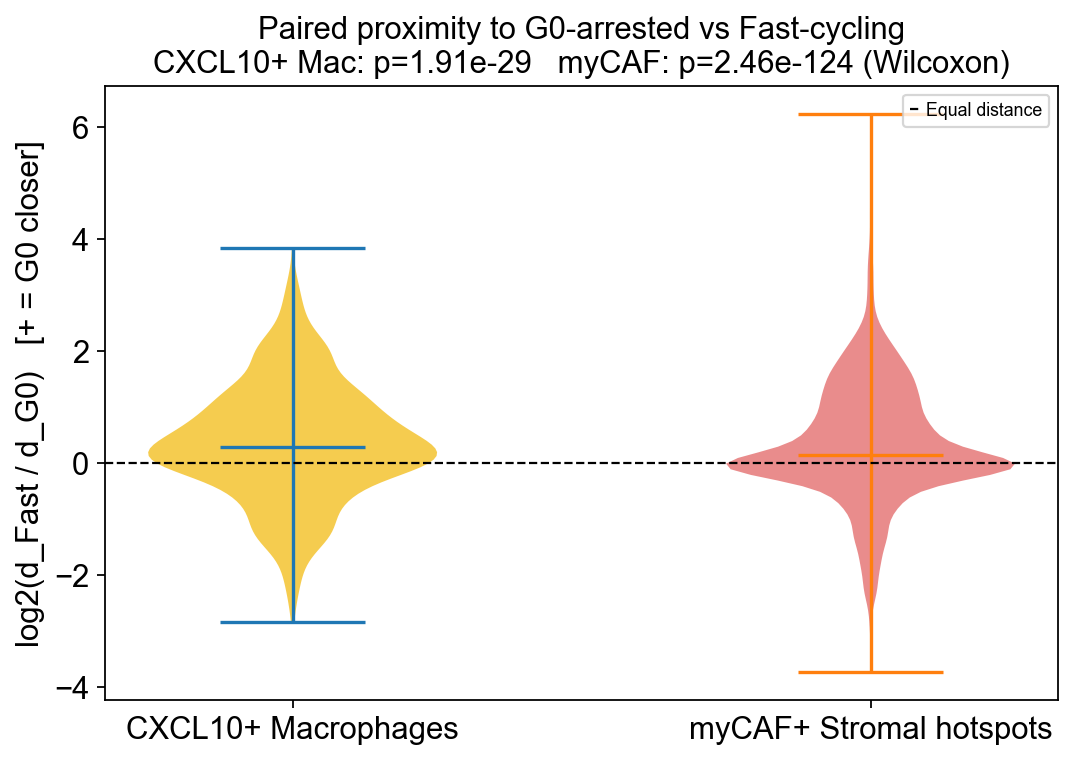

In [78]:
# Side-by-side violin plot: log2(d_Fast / d_G0) for CXCL10+ Macs and myCAFs
fig, ax = plt.subplots(figsize=(7, 5))

vp1 = ax.violinplot([mac_log2_ratio], positions=[0], showmedians=True)
vp2 = ax.violinplot([caf_log2_ratio], positions=[1], showmedians=True)

vp1["bodies"][0].set_facecolor("#F2B705")
vp1["bodies"][0].set_alpha(0.7)
vp2["bodies"][0].set_facecolor("#E05C5C")
vp2["bodies"][0].set_alpha(0.7)

ax.axhline(0, color="black", lw=1, linestyle="--", label="Equal distance")
ax.set_xticks([0, 1])
ax.set_xticklabels(["CXCL10+ Macrophages", "myCAF+ Stromal hotspots"])
ax.set_ylabel("log2(d_Fast / d_G0)   [+ = G0 closer]")
ax.set_title(
    f"Paired proximity to G0-arrested vs Fast-cycling\n"
    f"CXCL10+ Mac: p={mac_pval_w:.2e}   myCAF: p={caf_pval_w:.2e} (Wilcoxon)"
)
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(figure_dir + "xenium_combined_log2ratio_violin.pdf", dpi=300, bbox_inches="tight")
plt.show()

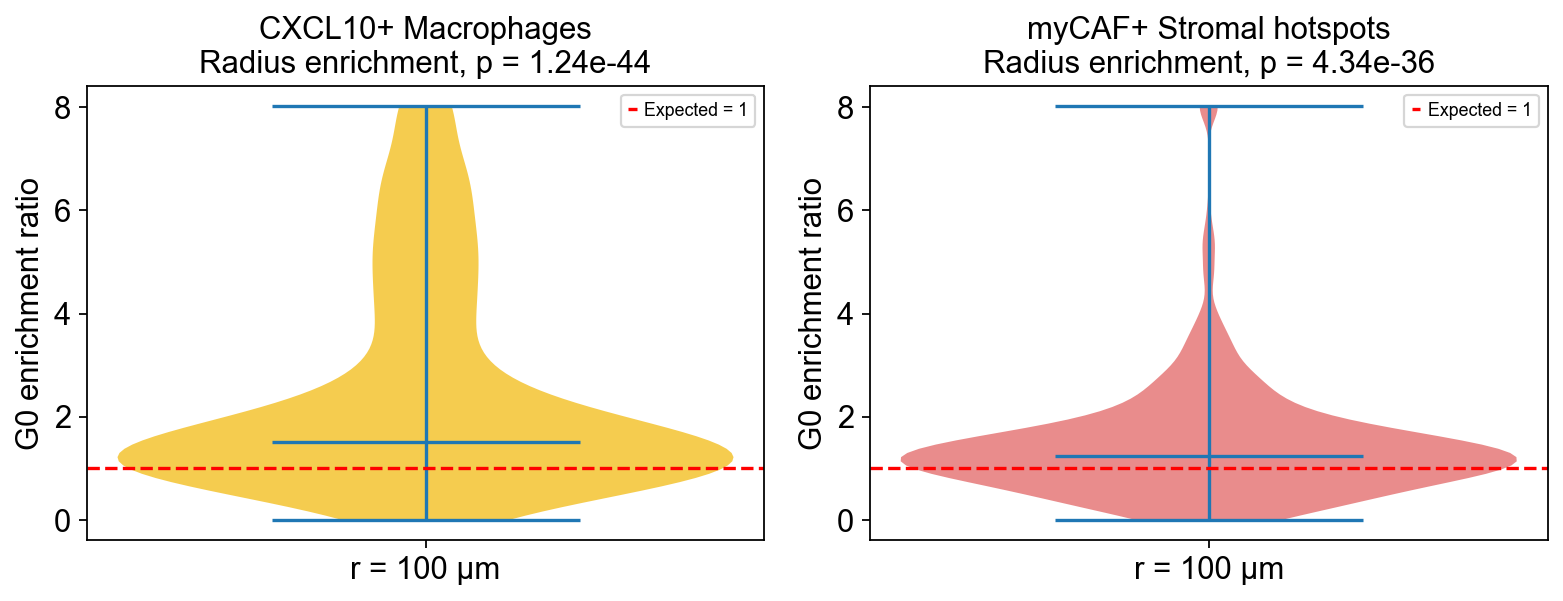

In [79]:
# Side-by-side enrichment ratio violin: CXCL10+ Macs vs myCAFs (r = 100 µm)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, valid, pval, title, color in zip(
    axes,
    [mac_valid_enrich, caf_valid_enrich],
    [mac_pval_radius, caf_pval_radius],
    ["CXCL10+ Macrophages", "myCAF+ Stromal hotspots"],
    ["#F2B705", "#E05C5C"],
):
    vp = ax.violinplot([valid], positions=[0], showmedians=True)
    vp["bodies"][0].set_facecolor(color)
    vp["bodies"][0].set_alpha(0.7)
    ax.axhline(1, color="red", lw=1.5, linestyle="--", label="Expected = 1")
    ax.set_xticks([0])
    ax.set_xticklabels([f"r = {r} µm"])
    ax.set_ylabel("G0 enrichment ratio")
    ax.set_title(f"{title}\nRadius enrichment, p = {pval:.2e}")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(figure_dir + "xenium_combined_radius_enrichment.pdf", dpi=300, bbox_inches="tight")
plt.show()

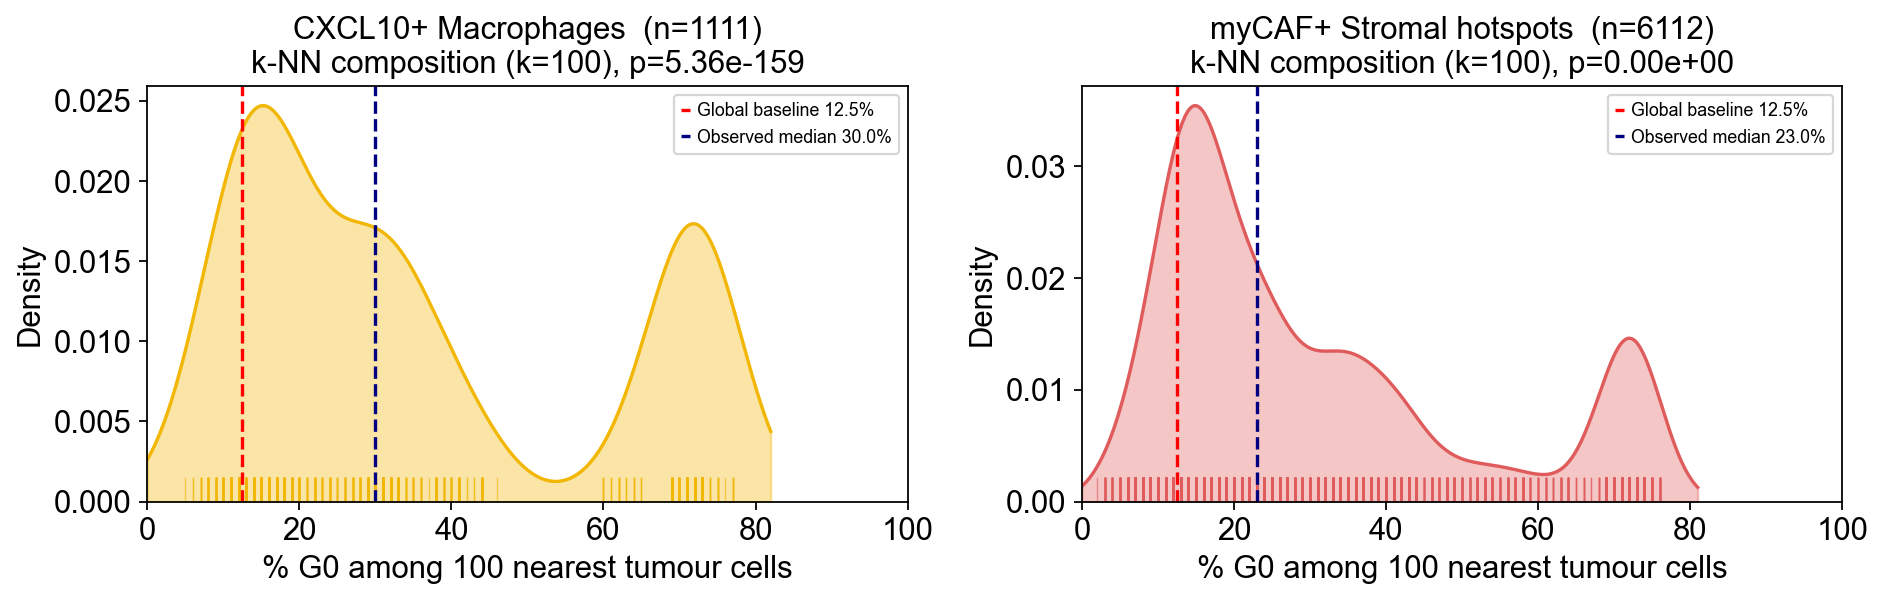

In [80]:
# Side-by-side k-NN G0 fraction comparison
# KDE used for both panels — robust to small n (CAF hotspots may be few)
from scipy.stats import gaussian_kde

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, fracs, pval, title, color in zip(
    axes,
    [mac_g0_fracs_knn, caf_g0_fracs_knn],
    [mac_pval_knn, caf_pval_knn],
    ["CXCL10+ Macrophages", "myCAF+ Stromal hotspots"],
    ["#F2B705", "#E05C5C"],
):
    fracs_pct = fracs * 100
    n = len(fracs_pct)

    # KDE curve
    kde = gaussian_kde(fracs_pct, bw_method="scott")
    x_grid = np.linspace(max(0, fracs_pct.min() - 5), min(100, fracs_pct.max() + 5), 500)
    ax.fill_between(x_grid, kde(x_grid), alpha=0.35, color=color)
    ax.plot(x_grid, kde(x_grid), color=color, lw=1.5)

    # Rug plot (always; more visible for small n)
    rug_height = kde(x_grid).max() * 0.06
    for xv in fracs_pct:
        ax.plot([xv, xv], [0, rug_height], color=color, alpha=0.6,
                lw=(2.0 if n < 30 else 0.6))

    ax.axvline(global_g0_frac * 100, color="red", lw=1.5, linestyle="--",
               label=f"Global baseline {global_g0_frac*100:.1f}%")
    ax.axvline(np.median(fracs_pct), color="navy", lw=1.5, linestyle="--",
               label=f"Observed median {np.median(fracs_pct):.1f}%")

    ax.set_xlabel(f"% G0 among {k} nearest tumour cells")
    ax.set_ylabel("Density")
    ax.set_title(f"{title}  (n={n})\nk-NN composition (k={k}), p={pval:.2e}")
    ax.legend(fontsize=8)
    ax.set_xlim(0, 100)
    ax.set_ylim(bottom=0)

plt.tight_layout()
plt.savefig(figure_dir + "xenium_combined_knn_enrichment.pdf", dpi=300, bbox_inches="tight")
plt.show()